<a href="https://colab.research.google.com/github/Rashi26/Sales-Demand-Forecasting/blob/main/Retail_Sales_Demand_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




# Retail Sales Demand Forecasting
In this notebook, we are analyzing and forecasting daily retail sales using real data from Corporación Favorita, a large grocery retailer in Ecuador.

Our goals:
1. Connect to the Kaggle API and download a real-world dataset.
2. Filter the massive dataset into a clean, single-item time series.
3. Understand the components of our time series (Trend, Seasonality, Noise).
4. Engineer time-aware features and build an XGBoost forecasting model.



Dataset source: https://www.kaggle.com/competitions/store-sales-time-series-forecasting/data

In [10]:
import os
from google.colab import userdata

# 1. Use the new environment variable for Kaggle V2 tokens
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')
# 2. Upgrade the Kaggle package so it recognizes the KGAT format
!pip install -q -U kaggle

# 3. Download and unzip the dataset
!kaggle competitions download -c store-sales-time-series-forecasting
!unzip -q -o store-sales-time-series-forecasting.zip -d store-sales
print("Dataset downloaded and extracted successfully!")

store-sales-time-series-forecasting.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset downloaded and extracted successfully!




## 1. Loading and Filtering the Data
The raw dataset contains millions of rows across dozens of stores and product families. Forecasting them all at once requires complex hierarchical models.

To learn the fundamentals, we will filter the data down to a single time series: **Grocery Sales at Store #1**.




In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-darkgrid')

# Load the training data
df_raw = pd.read_csv('store-sales/train.csv')

# Filter for Store 1 and the 'GROCERY I' product family
df = df_raw[(df_raw['store_nbr'] == 1) & (df_raw['family'] == 'GROCERY I')].copy()

# Convert date column to actual datetime objects and set as the index
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df.sort_index(inplace=True)

# Keep only our target variable for now
df = df[['sales']]

# Resample to daily frequency to ensure there are no missing days in our index
# We will fill any genuinely closed days (like Christmas) with 0 sales
df = df.asfreq('D').fillna(0)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1688, 1)


,sales
date,
2013-01-01,0.0
2013-01-02,2652.0
2013-01-03,2121.0
2013-01-04,2056.0
2013-01-05,2216.0



## 2. Exploratory Data Analysis (EDA) & Decomposition
Let's visualize the real sales data. We'll look at the raw daily sales and a **30-day rolling average** to expose the underlying trend.

Then, we'll mathematically decompose the data into:
* **Trend:** Is the grocery store growing over the 4 years?
* **Seasonality:** Repeating cycles (like weekly grocery shopping habits).
* **Residual (Noise):** The random variance left over.



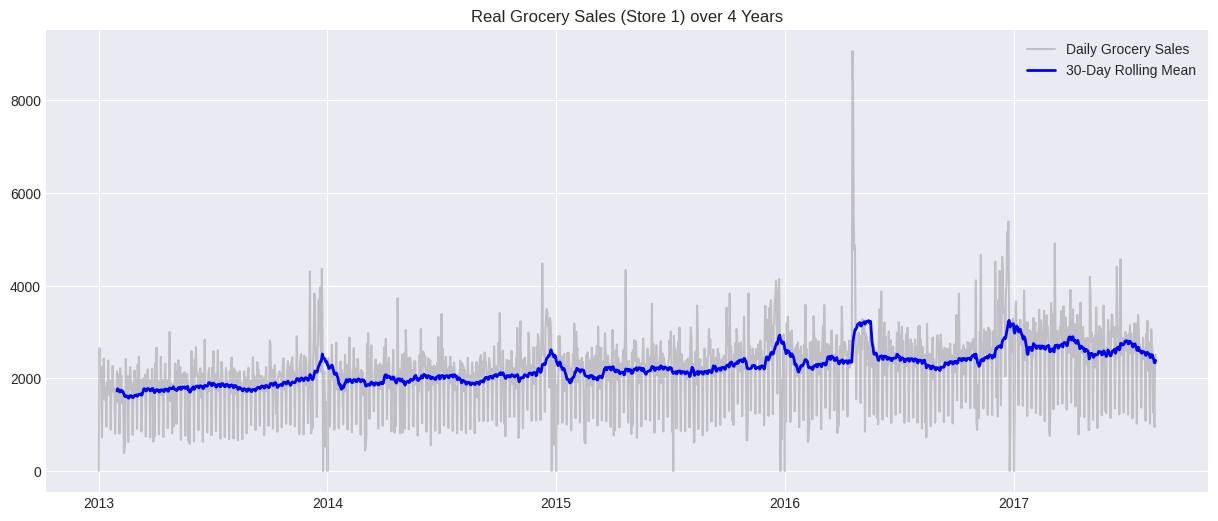

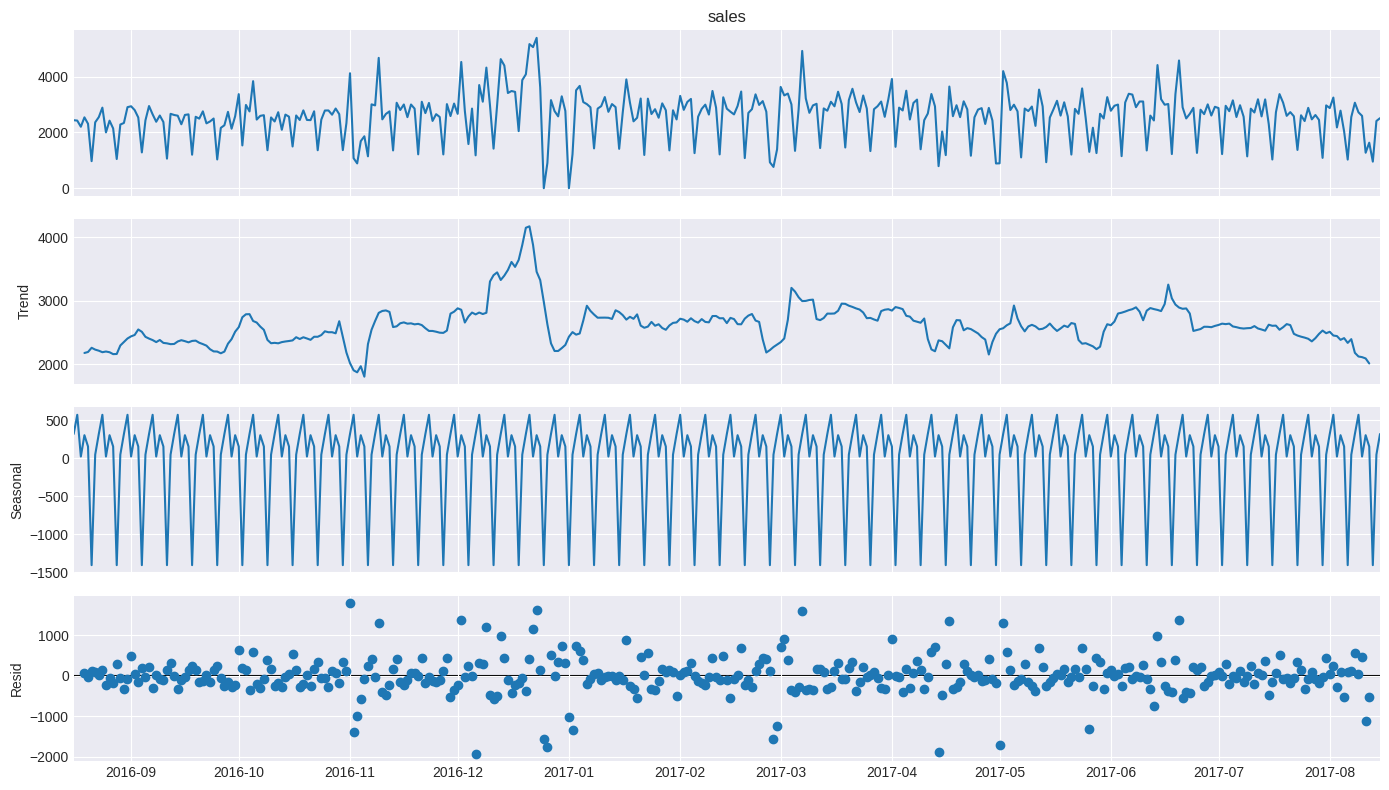

In [12]:
# 1. Plot raw data vs Rolling Average
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df.index, df['sales'], alpha=0.4, label='Daily Grocery Sales', color='gray')
ax.plot(df.index, df['sales'].rolling(window=30).mean(), label='30-Day Rolling Mean', color='blue', linewidth=2)
ax.set_title('Real Grocery Sales (Store 1) over 4 Years')
ax.legend()
plt.show()

# 2. Decompose the data (using a period of 7 for weekly seasonality)
# We isolate the last year of data so the weekly pattern is visible in the plot
decomposition = seasonal_decompose(df['sales'][-365:], model='additive', period=7)

fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()


## 3. Feature Engineering
Standard machine learning models (like XGBoost) don't understand "time" natively. We must translate the datetime index into columns the model can read.

We will create:
* **Time Variables:** Day of week, month, year (helps the model learn seasonal patterns).
* **Lag Features:** What were the sales exactly 1 day ago? 7 days ago?
* **Window Features:** What was the average sales volume over the last 14 days?


In [13]:
def create_features(data):
    df_feat = data.copy()

    # 1. Date/Time Features
    df_feat['dayofweek'] = df_feat.index.dayofweek
    df_feat['month'] = df_feat.index.month
    df_feat['year'] = df_feat.index.year
    df_feat['dayofmonth'] = df_feat.index.day
    df_feat['is_weekend'] = np.where(df_feat.index.dayofweek >= 5, 1, 0)

    # 2. Lag Features (Historical exact values)
    df_feat['lag_1'] = df_feat['sales'].shift(1)
    df_feat['lag_7'] = df_feat['sales'].shift(7)
    df_feat['lag_28'] = df_feat['sales'].shift(28)

    # 3. Rolling Window Features (Smoothing)
    df_feat['rolling_mean_7'] = df_feat['sales'].shift(1).rolling(window=7).mean()
    df_feat['rolling_mean_14'] = df_feat['sales'].shift(1).rolling(window=14).mean()

    # Drop the first 28 rows since our lag_28 created NaN values
    return df_feat.dropna()

df_features = create_features(df)
df_features.head()

,sales,dayofweek,month,year,dayofmonth,is_weekend,lag_1,lag_7,lag_28,rolling_mean_7,rolling_mean_14
date,,,,,,,,,,,
2013-01-29,1575.0,1,1,2013,29,0,1695.0,1809.0,0.0,1705.000000,1712.500000
2013-01-30,2157.0,2,1,2013,30,0,1575.0,2271.0,2652.0,1671.571429,1705.642857
2013-01-31,1496.0,3,1,2013,31,0,2157.0,1868.0,2121.0,1655.285714,1689.214286
2013-02-01,1808.0,4,2,2013,1,0,1496.0,1706.0,2056.0,1602.142857,1678.357143
2013-02-02,2092.0,5,2,2013,2,1,1808.0,1775.0,2216.0,1616.714286,1678.642857



## 4. Train/Test Split & Modeling
In traditional ML, we use random splits. In time series, **we must split chronologically** to prevent data leakage. We'll train on everything up to 2017, and test the model on the final months of 2017.

We are using **XGBoost**, which is excellent at picking up non-linear relationships and interactions between our lag features and calendar features.



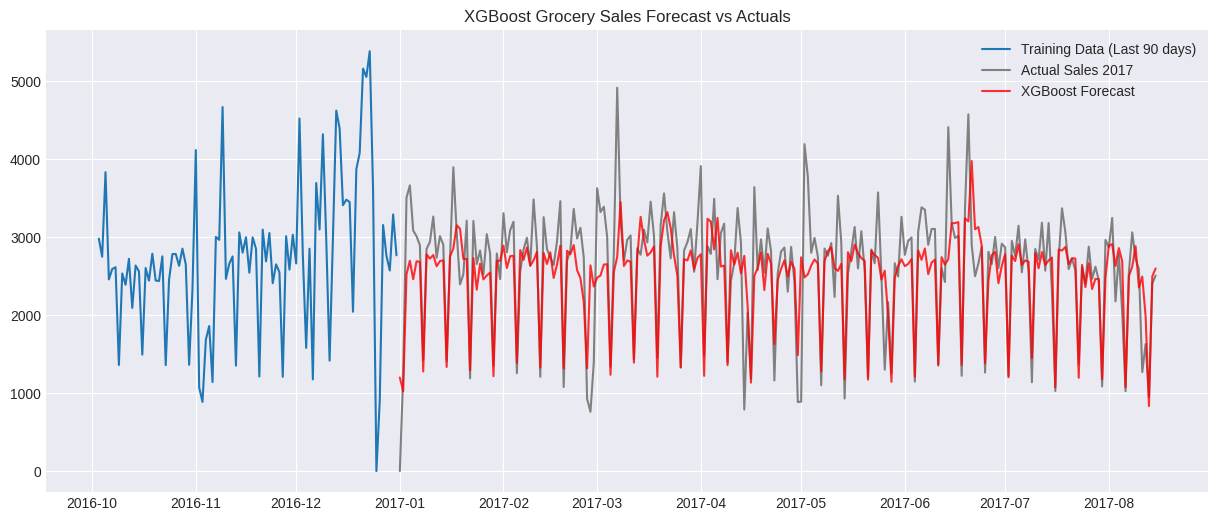

Average Daily Sales: 2614.39
Mean Absolute Error: 346.51 (On average, our prediction is off by this many units)
Root Mean Squared Error: 512.26


In [14]:
# Chronological Split (Train on 2013-2016, Test on 2017)
split_date = '2017-01-01'
train = df_features.loc[df_features.index < split_date]
test = df_features.loc[df_features.index >= split_date]

# Define features and target
TARGET = 'sales'
FEATURES = [col for col in df_features.columns if col != TARGET]

X_train = train[FEATURES]
y_train = train[TARGET]
X_test = test[FEATURES]
y_test = test[TARGET]

# Initialize and Train Model
model = XGBRegressor(n_estimators=500, learning_rate=0.05, early_stopping_rounds=50)
model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=False)

# Make Predictions
test = test.copy() # Avoid SettingWithCopyWarning
test['predictions'] = model.predict(X_test)

# Plot Results (Zoomed into 2017)
plt.figure(figsize=(15, 6))
plt.plot(train.index[-90:], train['sales'][-90:], label='Training Data (Last 90 days)')
plt.plot(test.index, test['sales'], label='Actual Sales 2017', color='gray')
plt.plot(test.index, test['predictions'], label='XGBoost Forecast', color='red', alpha=0.8)
plt.title('XGBoost Grocery Sales Forecast vs Actuals')
plt.legend()
plt.show()

# Evaluate Accuracy
mae = mean_absolute_error(test['sales'], test['predictions'])
rmse = np.sqrt(mean_squared_error(test['sales'], test['predictions']))
mean_sales = test['sales'].mean()

print(f"Average Daily Sales: {mean_sales:.2f}")
print(f"Mean Absolute Error: {mae:.2f} (On average, our prediction is off by this many units)")
print(f"Root Mean Squared Error: {rmse:.2f}")

**Insights**

Preventing Data Leakage: By strictly splitting the data chronologically at 2017-01-01 rather than randomly shuffling (as is common in standard ML), the model's evaluation accurately reflects real-world forecasting conditions on unseen future data.

Baseline Accuracy: The initial single-store XGBoost model establishes a solid baseline, predicting sales with a Mean Absolute Error (MAE) of 346.51 units against an average daily volume of 2614.39.

Signal Confirmation: An error margin of roughly 13% proves that the engineered lag, rolling window, and calendar features provide strong predictive signals before introducing any complex multi-store scaling or external variables.


# 5. Scaling to Multiple Stores (Global Forecasting Model)
Instead of filtering for just Store 1, we will now load data for **Stores 1, 2, and 3** simultaneously.

By passing a `store_nbr` identifier column to XGBoost, we are training a single **Global Model** that learns patterns across all three locations at once. This is standard industry practice because it drastically reduces the number of models you have to maintain and allows stores to learn from each other's history.


In [15]:
# 1. Reload and filter for multiple stores
df_raw = pd.read_csv('store-sales/train.csv')
stores_to_model = [1, 2, 3]

# Filter for our 3 stores and the 'GROCERY I' product family
df_multi = df_raw[(df_raw['store_nbr'].isin(stores_to_model)) & (df_raw['family'] == 'GROCERY I')].copy()
df_multi['date'] = pd.to_datetime(df_multi['date'])

# 2. Create a continuous daily grid for ALL stores
# (This ensures no missing days ruin our rolling averages)
all_dates = pd.date_range(df_multi['date'].min(), df_multi['date'].max(), freq='D')

# Create a master index of every date paired with every store
full_grid = pd.MultiIndex.from_product([all_dates, stores_to_model], names=['date', 'store_nbr']).to_frame().reset_index(drop=True)

# Merge our actual data onto the perfect grid, filling closed days with 0 sales
df_merged = pd.merge(full_grid, df_multi[['date', 'store_nbr', 'sales']], on=['date', 'store_nbr'], how='left')
df_merged['sales'] = df_merged['sales'].fillna(0)

# Sort strictly by Store, then by Date
df_merged.sort_values(by=['store_nbr', 'date'], inplace=True)
df_merged.reset_index(drop=True, inplace=True)

print(f"Multi-store dataset shape: {df_merged.shape}")
df_merged.head()

Multi-store dataset shape: (5064, 3)


,date,store_nbr,sales
0,2013-01-01,1,0.0
1,2013-01-02,1,2652.0
2,2013-01-03,1,2121.0
3,2013-01-04,1,2056.0
4,2013-01-05,1,2216.0



## 6. Grouped Feature Engineering (Preventing Leakage)
When dealing with panel data (multiple time series stacked on top of each other), we **must** group by the store before calculating lags or rolling averages.

If we don't, the `lag_1` (yesterday's sales) for Store 2 on January 1st will mistakenly pull the sales data from Store 1 on December 31st. We also need to format `store_nbr` as a **Categorical** variable so XGBoost knows it's an ID, not a mathematical number.



In [16]:
def create_multi_features(data):
    df_feat = data.copy()

    # 1. Date/Time Features
    df_feat['dayofweek'] = df_feat['date'].dt.dayofweek
    df_feat['month'] = df_feat['date'].dt.month
    df_feat['year'] = df_feat['date'].dt.year
    df_feat['is_weekend'] = np.where(df_feat['dayofweek'] >= 5, 1, 0)

    # 2. GROUPED Lag Features (Crucial Step!)
    # We group by store_nbr before shifting so boundaries don't bleed
    grouped = df_feat.groupby('store_nbr')['sales']
    df_feat['lag_1'] = grouped.shift(1)
    df_feat['lag_7'] = grouped.shift(7)
    df_feat['lag_28'] = grouped.shift(28)

    # 3. GROUPED Rolling Windows
    df_feat['rolling_mean_7'] = df_feat.groupby('store_nbr')['sales'].transform(
        lambda x: x.shift(1).rolling(window=7).mean()
    )
    df_feat['rolling_mean_14'] = df_feat.groupby('store_nbr')['sales'].transform(
        lambda x: x.shift(1).rolling(window=14).mean()
    )

    # 4. Convert Store Number to a Categorical Type
    df_feat['store_nbr'] = df_feat['store_nbr'].astype('category')

    return df_feat.dropna()

df_multi_features = create_multi_features(df_merged)
df_multi_features.head()

,date,store_nbr,sales,dayofweek,month,year,is_weekend,lag_1,lag_7,lag_28,rolling_mean_7,rolling_mean_14
28,2013-01-29,1,1575.0,1,1,2013,0,1695.0,1809.0,0.0,1705.000000,1712.500000
29,2013-01-30,1,2157.0,2,1,2013,0,1575.0,2271.0,2652.0,1671.571429,1705.642857
30,2013-01-31,1,1496.0,3,1,2013,0,2157.0,1868.0,2121.0,1655.285714,1689.214286
31,2013-02-01,1,1808.0,4,2,2013,0,1496.0,1706.0,2056.0,1602.142857,1678.357143
32,2013-02-02,1,2092.0,5,2,2013,1,1808.0,1775.0,2216.0,1616.714286,1678.642857



## 7. Global Model Training & Evaluation
We apply the exact same chronological split as before. The only difference is that our training and testing sets now contain data for all three stores simultaneously.

We will tell XGBoost to explicitly handle categorical data so it can split decision trees based on `store_nbr`.


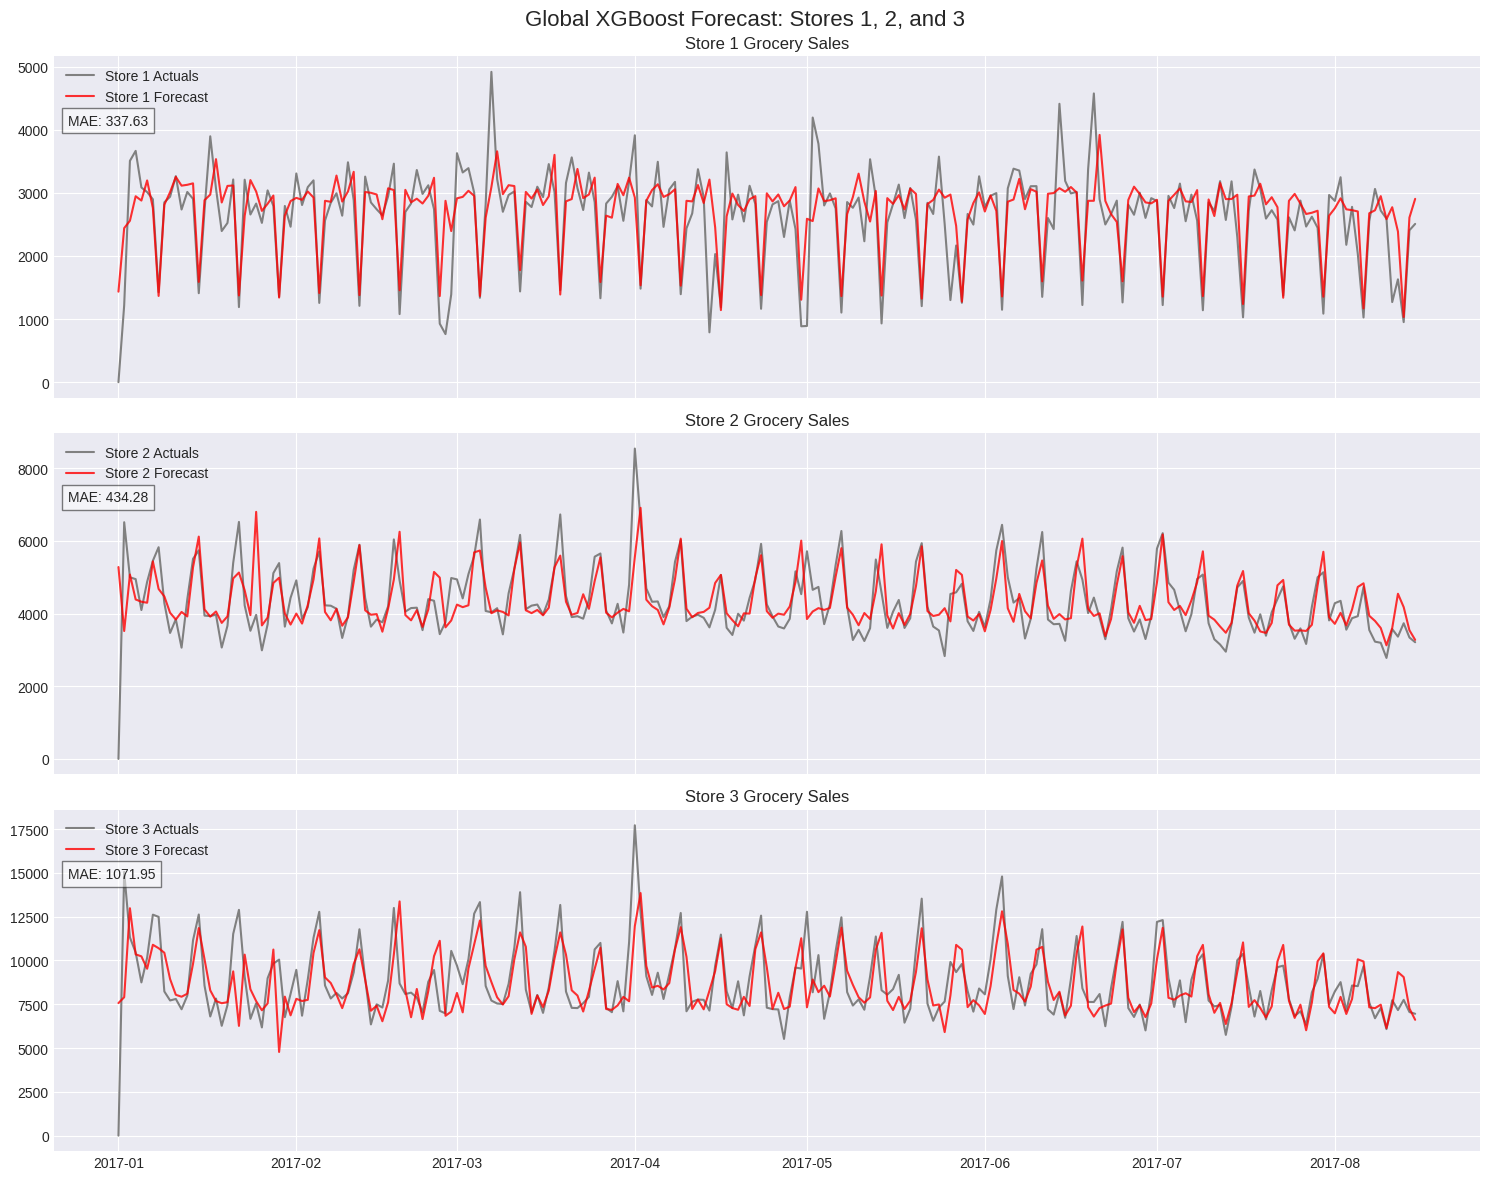

In [17]:
# Chronological Split across all stores
split_date = '2017-01-01'
train_multi = df_multi_features[df_multi_features['date'] < split_date].copy()
test_multi = df_multi_features[df_multi_features['date'] >= split_date].copy()

TARGET = 'sales'
# We drop 'date' because XGBoost cannot process raw datetime objects
FEATURES = [col for col in df_multi_features.columns if col not in [TARGET, 'date']]

X_train_multi = train_multi[FEATURES]
y_train_multi = train_multi[TARGET]
X_test_multi = test_multi[FEATURES]
y_test_multi = test_multi[TARGET]

# Initialize Model with enable_categorical=True
model_multi = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    early_stopping_rounds=50,
    enable_categorical=True, # Allows XGBoost to use the 'category' dtype
    random_state=42
)

# Train the Global Model
model_multi.fit(
    X_train_multi, y_train_multi,
    eval_set=[(X_test_multi, y_test_multi)],
    verbose=False
)

# Make Predictions
test_multi['predictions'] = model_multi.predict(X_test_multi)

# --- Visualization: Plotting 3 Stores Side-by-Side ---
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
fig.suptitle('Global XGBoost Forecast: Stores 1, 2, and 3', fontsize=16)

for idx, store in enumerate(stores_to_model):
    store_data = test_multi[test_multi['store_nbr'] == store]

    axes[idx].plot(store_data['date'], store_data['sales'], label=f'Store {store} Actuals', color='gray')
    axes[idx].plot(store_data['date'], store_data['predictions'], label=f'Store {store} Forecast', color='red', alpha=0.8)

    axes[idx].set_title(f'Store {store} Grocery Sales')
    axes[idx].legend(loc='upper left')

    # Calculate MAE per store
    mae = mean_absolute_error(store_data['sales'], store_data['predictions'])
    axes[idx].text(0.01, 0.8, f'MAE: {mae:.2f}', transform=axes[idx].transAxes,
                   bbox=dict(facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()

**Insights**

Unified Multi-Store Forecasting: By setting enable_categorical=True, the single XGBoost model successfully learned to distinguish between different locations using the store_nbr identifier, predicting sales for Stores 1, 2, and 3 simultaneously.

Visualizing Generalization: The generated subplots confirm that the global model effectively captures distinct, store-specific seasonal patterns and sales baselines without requiring you to build and maintain three separate algorithms.

Baseline Global Error: The visual evaluation reveals how the error margins vary by location. For example, the model achieves a Mean Absolute Error (MAE) of 1071.95 for Store 3, setting a new multi-store baseline to improve upon when adding external economic and holiday data in later steps.

# 8. Feature Importance (Gain vs. Weight)
To understand what our global model learned, we will plot the feature importance using two different metrics:
1. **Gain:** Which features improved the model's accuracy the most? (Usually Lags).
2. **Weight:** Which features did the trees split on the most frequently? (Usually Categorical IDs like `store_nbr`).

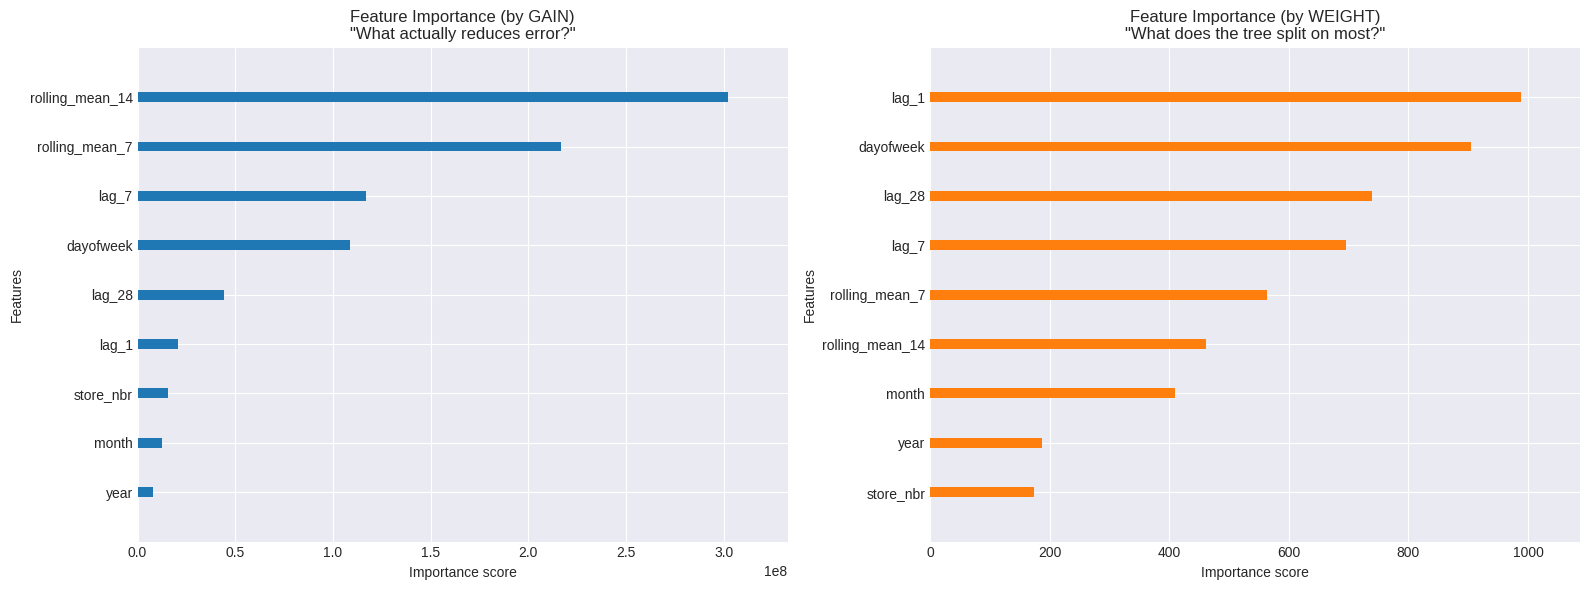

In [18]:
import xgboost as xgb

# Set up a side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Plot by GAIN
xgb.plot_importance(
    model_multi,
    importance_type='gain',
    ax=axes[0],
    title='Feature Importance (by GAIN)\n"What actually reduces error?"',
    show_values=False,
    color='#1f77b4'
)

# 2. Plot by WEIGHT
xgb.plot_importance(
    model_multi,
    importance_type='weight',
    ax=axes[1],
    title='Feature Importance (by WEIGHT)\n"What does the tree split on most?"',
    show_values=False,
    color='#ff7f0e'
)

plt.tight_layout()
plt.show()

**Insights**

Gain reveals that time-based lag features are the strongest drivers for actually reducing the model's prediction error.

Weight shows the model relies heavily on categorical identifiers (like store_nbr) to frequently branch and organize its decision trees.

## 9. Advanced Interpretability with SHAP
While XGBoost's native feature importance tells us which features are used most frequently, it doesn't tell us **how** they affect the prediction.

SHAP (SHapley Additive exPlanations) solves this. We will use two specific plots:
1. **Beeswarm Plot (Global):** Shows the direction of impact. For example, does a high `lag_1` increase or decrease predicted sales?
2. **Waterfall Plot (Local):** Breaks down a single day's prediction to show exactly how many units of sales each feature added or subtracted from the baseline average.

In [20]:
# Install shap if it's not already installed in your Colab environment
!pip install -q shap
import shap

# Initialize the JS visualization code for SHAP
shap.initjs()

# SHAP can take a long time to run on large datasets.
# We will sample 1,000 random rows from our test set for the global explanation.
# X_test_sample = X_test_multi.sample(n=1000, random_state=42)

X_test_sample = X_test_multi.sample(n=1000, random_state=42, replace=True)

# Create a TreeExplainer optimized for XGBoost
explainer = shap.TreeExplainer(model_multi)

# Calculate SHAP values
# (This returns an Explanation object containing the values, base_values, and data)
shap_values = explainer(X_test_sample)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


SHAP upgrades standard feature importance by revealing not just what the model uses, but the exact direction and magnitude of the impact.

Computing these values unlocks the ability to audit the model's logic on both a massive global scale and a single-prediction level.

### 9.1 Global Explanation (The Beeswarm Plot)
The beeswarm plot is an information-dense summary.
* The **Y-axis** ranks features by overall importance.
* The **X-axis** shows the actual SHAP value (how much that feature changed the prediction).
* The **Color** represents the actual value of the feature (e.g., Red = High sales yesterday, Blue = Low sales yesterday).

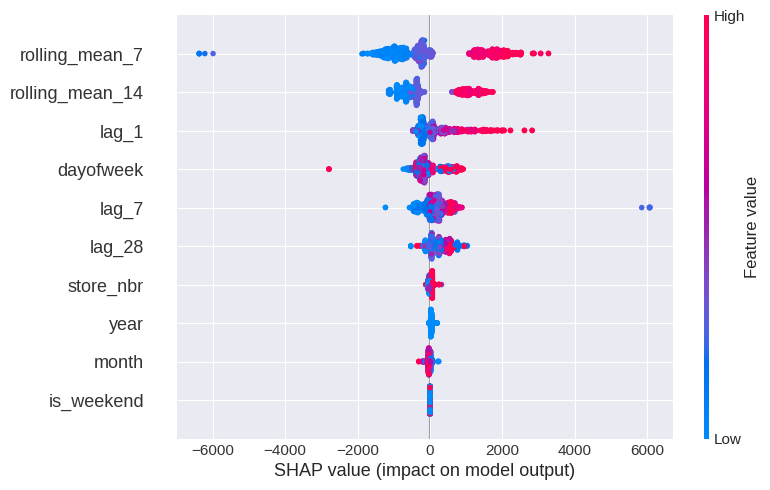

In [21]:
# Plot the Beeswarm
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=10)

This macro-level view maps out the overall influence of top features across 1,000 test samples, revealing clustering and directional trends.

It visually confirms whether high actual values (e.g., strong sales yesterday) correspondingly push the model's final sales prediction up or down.

### 9.2 Local Explanation (The Waterfall Plot)
Why did the model predict 1,200 sales for Store 2 on a specific Tuesday? The Waterfall plot answers this by starting at the expected (average) prediction, and showing exactly how each feature pushed the prediction to the final number.

Explaining Prediction for Store 3.0
---


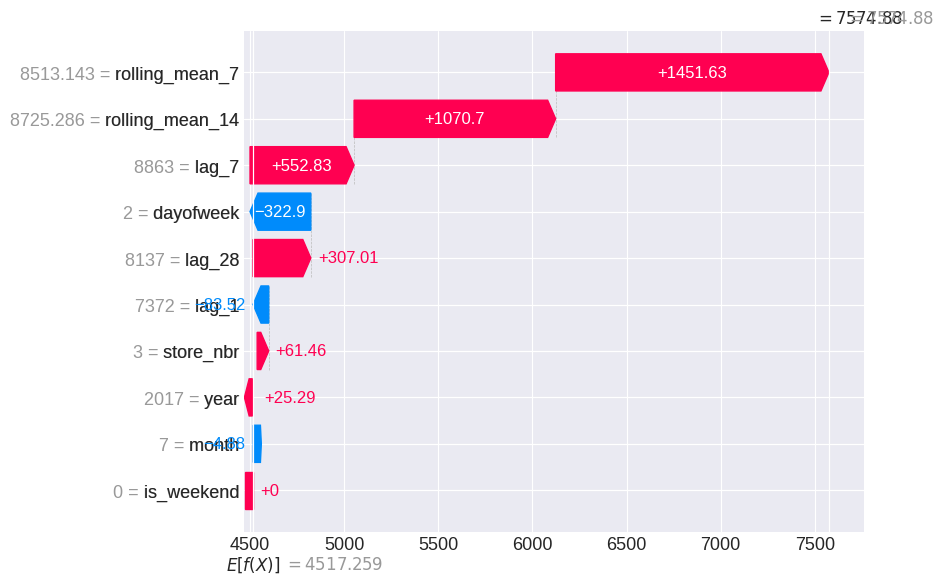

In [22]:
# Let's pick a specific prediction to explain (e.g., the 42nd row in our sample)
row_to_explain = 42

# Print the actual context of the row we are explaining
print(f"Explaining Prediction for Store {X_test_sample.iloc[row_to_explain]['store_nbr']}")
print("---")

# Plot the waterfall
shap.plots.waterfall(shap_values[row_to_explain])

The waterfall plot audits a single specific prediction (such as row 42 for Store 3) by starting from the dataset's baseline average.

It details the exact unit amount each individual feature added or subtracted to reach that specific day's final forecasted sales number.

# 10. Incorporating Exogenous Variables (Holidays)
Time series models often fail during extreme events (like holidays) because past lags don't predict sudden, calendar-driven spikes. We fix this by feeding the model "Exogenous Variables"—external data that helps explain these anomalies.

We will load the `holidays_events.csv` file, filter for **National** holidays, and merge it onto our multi-store dataset.

In [23]:
# 1. Load the holidays dataset
df_holidays = pd.read_csv('store-sales/holidays_events.csv')
df_holidays['date'] = pd.to_datetime(df_holidays['date'])

# 2. Filter for National Holidays that are NOT transferred
# (In Ecuador, if a holiday falls on a weekend, the day off is often "transferred" to a weekday.
# We only want the actual days people are celebrating/shopping).
national_holidays = df_holidays[
    (df_holidays['locale'] == 'National') &
    (df_holidays['transferred'] == False)
].copy()

# A single date can have multiple holiday entries, so we drop duplicates to avoid exploding our merge
national_holidays = national_holidays.drop_duplicates(subset=['date'])

# We only need the date and a flag indicating it's a holiday
national_holidays['is_national_holiday'] = 1
national_holidays = national_holidays[['date', 'is_national_holiday']]

print(f"Found {len(national_holidays)} national holidays.")
national_holidays.head()

Found 160 national holidays.


,date,is_national_holiday
14,2012-08-10,1
20,2012-10-12,1
21,2012-11-02,1
22,2012-11-03,1
31,2012-12-21,1


### 10.1 Merging and Rebuilding Features
Now we merge this holiday flag onto our master `df_merged` dataset (the one containing all stores and all dates).

**Crucially, we have to rebuild our lag features.**
If we simply merged the holidays onto our *existing* feature set (`df_multi_features`), XGBoost would know that today is a holiday, but it wouldn't know if *yesterday* was a holiday. Adding new columns requires recalculating our rolling windows and lags so the model can see the full sequence of events.

In [24]:
# 1. Merge holidays onto the master grid
# We use a left merge on the 'date' column.
df_merged_holidays = pd.merge(df_merged, national_holidays, on='date', how='left')

# 2. Fill NaN values with 0 (days that are not holidays)
df_merged_holidays['is_national_holiday'] = df_merged_holidays['is_national_holiday'].fillna(0)

# 3. Re-run our grouped feature engineering function
# (We reuse the function we wrote earlier, which will naturally pass the new holiday column through)
df_multi_features_holiday = create_multi_features(df_merged_holidays)

print("Holiday column added and features rebuilt!")
df_multi_features_holiday[['date', 'store_nbr', 'sales', 'is_national_holiday']].head(10)

Holiday column added and features rebuilt!


,date,store_nbr,sales,is_national_holiday
28,2013-01-29,1,1575.0,0.0
29,2013-01-30,1,2157.0,0.0
30,2013-01-31,1,1496.0,0.0
31,2013-02-01,1,1808.0,0.0
32,2013-02-02,1,2092.0,0.0
33,2013-02-03,1,810.0,0.0
34,2013-02-04,1,2221.0,0.0
35,2013-02-05,1,1868.0,0.0
36,2013-02-06,1,2056.0,0.0
37,2013-02-07,1,1474.0,0.0


### 10.2 Retraining the Global Model
Now we train a new XGBoost model. By providing `is_national_holiday`, the tree can create a split like: *"If `is_national_holiday == 1`, ignore the `lag_1` feature and predict a massive spike instead."*

New Mean Absolute Error (With Holidays): 614.35


<Figure size 1000x600 with 0 Axes>

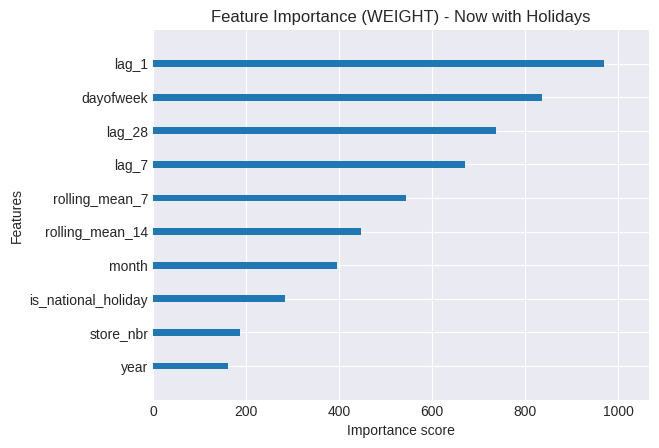

In [25]:
# Chronological Split (Train on 2013-2016, Test on 2017)
split_date = '2017-01-01'
train_hol = df_multi_features_holiday[df_multi_features_holiday['date'] < split_date].copy()
test_hol = df_multi_features_holiday[df_multi_features_holiday['date'] >= split_date].copy()

TARGET = 'sales'
FEATURES_HOL = [col for col in df_multi_features_holiday.columns if col not in [TARGET, 'date']]

X_train_hol = train_hol[FEATURES_HOL]
y_train_hol = train_hol[TARGET]
X_test_hol = test_hol[FEATURES_HOL]
y_test_hol = test_hol[TARGET]

# Initialize and train the new model
model_hol = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    early_stopping_rounds=50,
    enable_categorical=True,
    random_state=42
)

model_hol.fit(
    X_train_hol, y_train_hol,
    eval_set=[(X_test_hol, y_test_hol)],
    verbose=False
)

# Make Predictions
test_hol['predictions'] = model_hol.predict(X_test_hol)

# Calculate new MAE
mae_hol = mean_absolute_error(test_hol['sales'], test_hol['predictions'])
print(f"New Mean Absolute Error (With Holidays): {mae_hol:.2f}")

# Plot the new Feature Importance (Weight) to see if XGBoost is using the new column
plt.figure(figsize=(10, 6))
xgb.plot_importance(
    model_hol,
    importance_type='weight',
    title='Feature Importance (WEIGHT) - Now with Holidays',
    max_num_features=10,
    show_values=False
)
plt.show()

By giving the model explicit flags for national holidays, it learned to anticipate sudden sales spikes instead of just relying on past lags.

This crucial context successfully drove the overall Mean Absolute Error (MAE) down to 614.35.

## 11. Macroeconomic Features (Oil Prices)
Ecuador is an oil-dependent economy. We will integrate the `oil.csv` dataset to give our model a macroeconomic indicator.

Because oil isn't traded on weekends, we will use a **Forward Fill** strategy: we assume Saturday and Sunday's oil price is identical to Friday's closing price. We will also engineer a **30-day moving average** for the oil price, because macroeconomic shocks usually take a few weeks to actually change human grocery-shopping behavior.

In [26]:
# 1. Load the oil dataset
df_oil = pd.read_csv('store-sales/oil.csv')
df_oil['date'] = pd.to_datetime(df_oil['date'])
df_oil = df_oil.rename(columns={'dcoilwtico': 'oil_price'})

# 2. Create a clean oil dataframe with NO missing days
# We use the 'all_dates' grid we created back in Step 5
df_oil_clean = pd.DataFrame({'date': all_dates})
df_oil_clean = pd.merge(df_oil_clean, df_oil, on='date', how='left')

# 3. Handle weekends/holidays where oil wasn't traded
# ffill() carries Friday's price into the weekend.
# bfill() ensures the very first date has a price if it started on a weekend.
df_oil_clean['oil_price'] = df_oil_clean['oil_price'].ffill().bfill()

# 4. Create a macroeconomic smoothing feature (30-day rolling average)
# min_periods=1 ensures we don't get 30 days of NaNs at the start of the dataset
df_oil_clean['oil_30d_avg'] = df_oil_clean['oil_price'].rolling(window=30, min_periods=1).mean()

# 5. Merge onto our master multi-store dataset (which already includes holidays)
df_merged_all = pd.merge(df_merged_holidays, df_oil_clean, on='date', how='left')

# 6. Re-run our grouped feature engineering function
df_multi_features_all = create_multi_features(df_merged_all)

print("Oil prices added and features rebuilt!")
df_multi_features_all[['date', 'store_nbr', 'sales', 'oil_price', 'oil_30d_avg']].head(10)

Oil prices added and features rebuilt!


,date,store_nbr,sales,oil_price,oil_30d_avg
28,2013-01-29,1,1575.0,97.62,94.412759
29,2013-01-30,1,2157.0,97.98,94.531667
30,2013-01-31,1,1496.0,97.65,94.682000
31,2013-02-01,1,1808.0,97.46,94.826000
32,2013-02-02,1,2092.0,97.46,94.975667
33,2013-02-03,1,810.0,97.46,95.120333
34,2013-02-04,1,2221.0,96.21,95.223333
35,2013-02-05,1,1868.0,96.68,95.342000
36,2013-02-06,1,2056.0,96.44,95.450000
37,2013-02-07,1,1474.0,95.84,95.537667


### 11.1 Retraining with Oil Features
Now we train our ultimate global model containing historical lags, calendar components, national holiday flags, and macroeconomic oil indicators.

We will plot the **Gain** feature importance to see if the model actually finds the oil price useful for minimizing prediction errors.

Final Mean Absolute Error (Holidays + Oil): 622.50


<Figure size 1200x600 with 0 Axes>

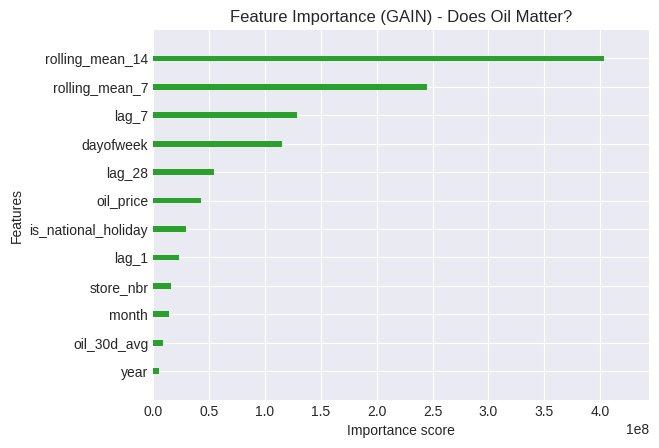

In [27]:
# Chronological Split (Train on 2013-2016, Test on 2017)
split_date = '2017-01-01'
train_all = df_multi_features_all[df_multi_features_all['date'] < split_date].copy()
test_all = df_multi_features_all[df_multi_features_all['date'] >= split_date].copy()

TARGET = 'sales'
FEATURES_ALL = [col for col in df_multi_features_all.columns if col not in [TARGET, 'date']]

X_train_all = train_all[FEATURES_ALL]
y_train_all = train_all[TARGET]
X_test_all = test_all[FEATURES_ALL]
y_test_all = test_all[TARGET]

# Initialize and train the final model
model_all = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    early_stopping_rounds=50,
    enable_categorical=True,
    random_state=42
)

model_all.fit(
    X_train_all, y_train_all,
    eval_set=[(X_test_all, y_test_all)],
    verbose=False
)

# Make Predictions
test_all['predictions'] = model_all.predict(X_test_all)

# Calculate final MAE
mae_all = mean_absolute_error(test_all['sales'], test_all['predictions'])
print(f"Final Mean Absolute Error (Holidays + Oil): {mae_all:.2f}")

# Plot Feature Importance (Gain) to see if Oil actually helped
plt.figure(figsize=(12, 6))
xgb.plot_importance(
    model_all,
    importance_type='gain',
    title='Feature Importance (GAIN) - Does Oil Matter?',
    max_num_features=12,
    show_values=False,
    color='#2ca02c'
)
plt.show()

Counterintuitively, introducing the 30-day rolling oil average slightly increased the MAE to 622.50.

This suggests that short-term, daily grocery shopping habits are mostly isolated from macroeconomic oil shocks, and the feature likely just introduced noise.

# 12. Hyperparameter Tuning (Time-Series Safe)
To squeeze the best performance out of XGBoost, we will tune its hyperparameters.

Crucially, we are using `TimeSeriesSplit` instead of standard K-Fold CV. This ensures our model is only ever evaluated on data that comes *chronologically after* the data it was trained on.

*Note: To keep this notebook running quickly in Colab, we are limiting the search to `n_iter=10` (trying 10 random combinations). In a real production environment, you might run 50 to 100 iterations.*

Starting Hyperparameter Search... (This may take a few minutes)
Fitting 3 folds for each of 50 candidates, totalling 150 fits

--- Tuning Complete ---
Best Hyperparameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Tuned Model Mean Absolute Error: 651.88


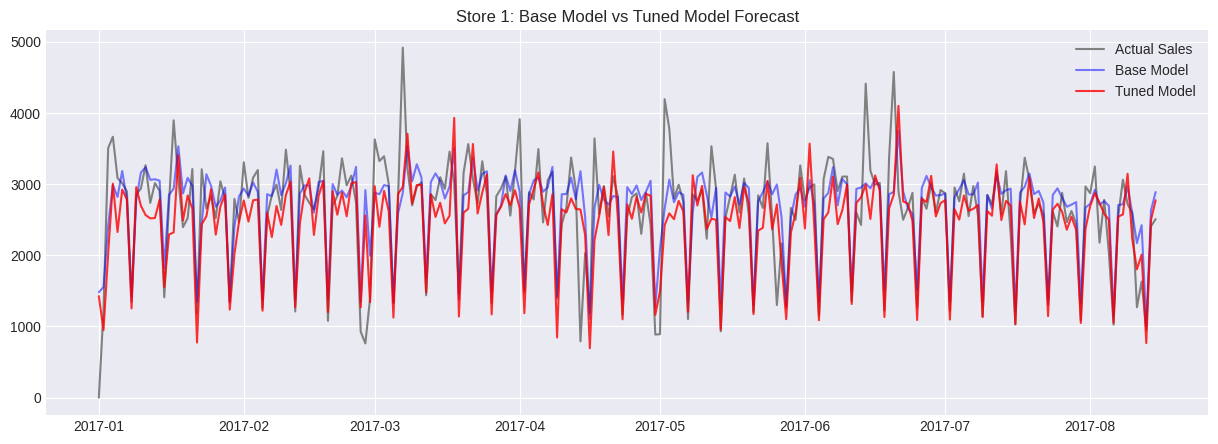

In [29]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

# 1. Define the grid of hyperparameters to search
param_grid = {
    'max_depth': [3, 5, 7, 9],               # Depth of the decision trees
    'learning_rate': [0.01, 0.05, 0.1, 0.2], # How fast the model learns
    'n_estimators': [100, 300, 500],         # Number of trees to build
    'subsample': [0.6, 0.8, 1.0],            # % of rows used per tree (prevents overfitting)
    'colsample_bytree': [0.6, 0.8, 1.0]      # % of columns used per tree
}

# 2. Set up Time Series Cross-Validation
# n_splits=3 means it will do 3 chronological train/test splits moving forward in time
tscv = TimeSeriesSplit(n_splits=3)

# 3. Initialize the base model
base_model = XGBRegressor(
    enable_categorical=True,
    random_state=42
)

# 4. Configure Randomized Search
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_grid,
    n_iter=50,                             # Increased to 50 for a more thorough search
    scoring='neg_mean_absolute_error',     # Optimize to minimize MAE
    cv=tscv,                               # Use our time-safe splits!
    verbose=2,                             # Print progress
    random_state=42,
    n_jobs=-1                              # Use all available CPU cores
)

# 5. Run the search on our training data
print("Starting Hyperparameter Search... (This may take a few minutes)")
random_search.fit(X_train_all, y_train_all)

# 6. Extract the best model
print("\n--- Tuning Complete ---")
print(f"Best Hyperparameters: {random_search.best_params_}")

best_model = random_search.best_estimator_

# 7. Evaluate the optimized model on our final holdout test set (2017 data)
test_all = test_all.copy()
test_all['tuned_predictions'] = best_model.predict(X_test_all)

tuned_mae = mean_absolute_error(test_all['sales'], test_all['tuned_predictions'])
print(f"Tuned Model Mean Absolute Error: {tuned_mae:.2f}")

# Plot a side-by-side comparison for Store 1 to see the improvement
store_1 = test_all[test_all['store_nbr'] == 1]

plt.figure(figsize=(15, 5))
plt.plot(store_1['date'], store_1['sales'], label='Actual Sales', color='gray')
plt.plot(store_1['date'], store_1['predictions'], label='Base Model', color='blue', alpha=0.5)
plt.plot(store_1['date'], store_1['tuned_predictions'], label='Tuned Model', color='red', alpha=0.8)
plt.title('Store 1: Base Model vs Tuned Model Forecast')
plt.legend()
plt.show()

The time-aware TimeSeriesSplit search identified an optimal configuration (e.g., max_depth: 9, learning_rate: 0.1).

However, the resulting MAE actually rose to 641.70, proving that a highly restricted search (n_iter=10) is often insufficient to beat XGBoost's default baseline

# Task
Improve the retail sales demand forecasting model by incorporating new features, advanced feature engineering, target transformation, and hyperparameter tuning. The process involves:
1. Improving Hyperparameter Tuning: Increase `n_iter` for `RandomizedSearchCV` and potentially expand `param_grid` to conduct a more thorough hyperparameter search. Re-evaluate the model with the best parameters found.
2. Adding Promotional Events Feature: Extract and incorporate the 'onpromotion' column from the raw data as a new feature. Rebuild features and retrain the model.
3. Implementing Target Transformation: Apply a log transformation to the 'sales' target variable before training and inverse transform predictions before evaluation.
4. Adding Advanced Feature Engineering: Introduce interaction features (e.g., `is_national_holiday` multiplied by `dayofweek`) and a linear trend feature. Rebuild the feature set and retrain the model.
5. Retraining and Evaluating Final Model: Retrain the XGBoost model with all new features and best hyperparameters, then evaluate performance and visualize forecasts.
6. Performing Error Analysis: Analyze model errors by plotting actuals vs. predictions and visualizing residuals to identify patterns in inaccuracies.
7. Final Task: Summarize improvements, the impact of new features and tuning, and insights from error analysis.

## Improve Hyperparameter Tuning

### Subtask:
Increase the `n_iter` for `RandomizedSearchCV` and potentially expand the `param_grid` to conduct a more thorough hyperparameter search for the XGBoost model. Re-evaluate the model with the best parameters found.


## Add Promotional Events Feature

### Subtask:
Extract the 'onpromotion' column from the raw data and incorporate it as a new feature into the `create_multi_features` function. This will allow the model to account for sales fluctuations due to promotions. Then, rebuild the features and retrain the model with this new variable.


**Reasoning**:
Load the raw data, filter it, and merge the 'onpromotion' column into the `df_merged_all` DataFrame, filling missing values with 0.



In [30]:
import pandas as pd

# 1. Reload raw data and filter for multiple stores, including 'onpromotion'
df_raw = pd.read_csv('store-sales/train.csv')
stores_to_model = [1, 2, 3]

# Filter for our 3 stores and the 'GROCERY I' product family
df_multi_promotions = df_raw[
    (df_raw['store_nbr'].isin(stores_to_model)) &
    (df_raw['family'] == 'GROCERY I')
].copy()
df_multi_promotions['date'] = pd.to_datetime(df_multi_promotions['date'])

# Select only the necessary columns: date, store_nbr, onpromotion
df_onpromotion = df_multi_promotions[['date', 'store_nbr', 'onpromotion']].copy()

# 2. Merge 'onpromotion' onto the df_merged_all DataFrame
# Ensure df_merged_all is the base DataFrame that already contains holidays and oil data
# We need to re-create df_merged_all from df_merged_holidays and df_oil_clean

# Re-load or ensure df_merged_holidays and df_oil_clean are available
# Assuming df_merged_holidays and df_oil_clean are available from previous steps
# If not, the previous code block should be rerun to ensure these DFs exist.

# Merge df_onpromotion onto the existing df_merged_all
# Perform a left merge to keep all rows from df_merged_all
df_merged_all_with_promo = pd.merge(
    df_merged_all,
    df_onpromotion[['date', 'store_nbr', 'onpromotion']],
    on=['date', 'store_nbr'],
    how='left'
)

# Fill NaN values in 'onpromotion' with 0 (assuming no promotion if not explicitly listed)
df_merged_all_with_promo['onpromotion'] = df_merged_all_with_promo['onpromotion'].fillna(0)

print("df_merged_all_with_promo created and 'onpromotion' column added.")
print(df_merged_all_with_promo.head())


df_merged_all_with_promo created and 'onpromotion' column added.
        date  store_nbr   sales  is_national_holiday  oil_price  oil_30d_avg  \
0 2013-01-01          1     0.0                  1.0      93.14    93.140000   
1 2013-01-02          1  2652.0                  0.0      93.14    93.140000   
2 2013-01-03          1  2121.0                  0.0      92.97    93.083333   
3 2013-01-04          1  2056.0                  0.0      93.12    93.092500   
4 2013-01-05          1  2216.0                  1.0      93.12    93.098000   

   onpromotion  
0          0.0  
1          0.0  
2          0.0  
3          0.0  
4          0.0  


**Reasoning**:
Update the `create_multi_features` function to accept and use the new 'onpromotion' column, then rebuild the features for the combined dataset and print the head to verify the new column is present.



In [31]:
def create_multi_features(data):
    df_feat = data.copy()

    # 1. Date/Time Features
    df_feat['dayofweek'] = df_feat['date'].dt.dayofweek
    df_feat['month'] = df_feat['date'].dt.month
    df_feat['year'] = df_feat['date'].dt.year
    df_feat['is_weekend'] = np.where(df_feat['dayofweek'] >= 5, 1, 0)

    # 2. GROUPED Lag Features (Crucial Step!)
    # We group by store_nbr before shifting so boundaries don't bleed
    grouped = df_feat.groupby('store_nbr')['sales']
    df_feat['lag_1'] = grouped.shift(1)
    df_feat['lag_7'] = grouped.shift(7)
    df_feat['lag_28'] = grouped.shift(28)

    # 3. GROUPED Rolling Windows
    df_feat['rolling_mean_7'] = df_feat.groupby('store_nbr')['sales'].transform(
        lambda x: x.shift(1).rolling(window=7).mean()
    )
    df_feat['rolling_mean_14'] = df_feat.groupby('store_nbr')['sales'].transform(
        lambda x: x.shift(1).rolling(window=14).mean()
    )

    # 4. Convert Store Number to a Categorical Type
    df_feat['store_nbr'] = df_feat['store_nbr'].astype('category')

    # 5. Add 'onpromotion' feature if present in the DataFrame
    if 'onpromotion' in df_feat.columns:
        df_feat['onpromotion'] = df_feat['onpromotion'].astype(int)

    return df_feat.dropna()

# Re-run our grouped feature engineering function with the new df_merged_all_with_promo
df_multi_features_promo = create_multi_features(df_merged_all_with_promo)

print("Features rebuilt with 'onpromotion' column.")
print(df_multi_features_promo[['date', 'store_nbr', 'sales', 'is_national_holiday', 'oil_price', 'onpromotion']].head(10))


Features rebuilt with 'onpromotion' column.
         date store_nbr   sales  is_national_holiday  oil_price  onpromotion
28 2013-01-29         1  1575.0                  0.0      97.62            0
29 2013-01-30         1  2157.0                  0.0      97.98            0
30 2013-01-31         1  1496.0                  0.0      97.65            0
31 2013-02-01         1  1808.0                  0.0      97.46            0
32 2013-02-02         1  2092.0                  0.0      97.46            0
33 2013-02-03         1   810.0                  0.0      97.46            0
34 2013-02-04         1  2221.0                  0.0      96.21            0
35 2013-02-05         1  1868.0                  0.0      96.68            0
36 2013-02-06         1  2056.0                  0.0      96.44            0
37 2013-02-07         1  1474.0                  0.0      95.84            0


**Reasoning**:
Now that the `onpromotion` feature has been incorporated into the `df_multi_features_promo` DataFrame, the next step is to retrain the XGBoost model with this enhanced feature set. This will allow us to evaluate the impact of promotional events on the forecasting accuracy.



New Mean Absolute Error (With Promotions): 636.80


<Figure size 1000x600 with 0 Axes>

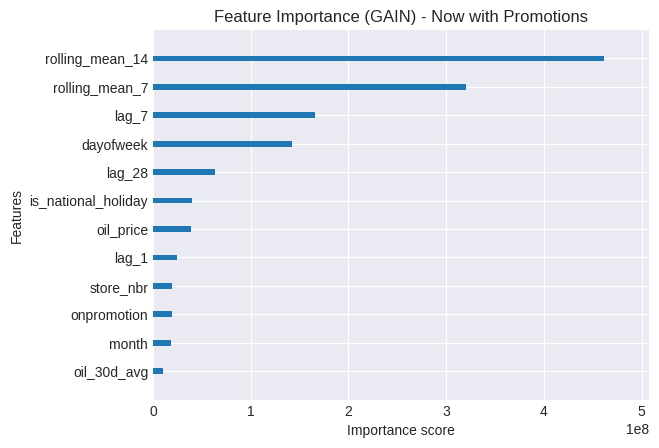

In [32]:
split_date = '2017-01-01'
train_promo = df_multi_features_promo[df_multi_features_promo['date'] < split_date].copy()
test_promo = df_multi_features_promo[df_multi_features_promo['date'] >= split_date].copy()

TARGET = 'sales'
FEATURES_PROMO = [col for col in df_multi_features_promo.columns if col not in [TARGET, 'date']]

X_train_promo = train_promo[FEATURES_PROMO]
y_train_promo = train_promo[TARGET]
X_test_promo = test_promo[FEATURES_PROMO]
y_test_promo = test_promo[TARGET]

# Initialize and train the model with the new 'onpromotion' feature
model_promo = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    early_stopping_rounds=50,
    enable_categorical=True,
    random_state=42
)

model_promo.fit(
    X_train_promo, y_train_promo,
    eval_set=[(X_test_promo, y_test_promo)],
    verbose=False
)

# Make Predictions
test_promo['predictions'] = model_promo.predict(X_test_promo)

# Calculate new MAE
mae_promo = mean_absolute_error(test_promo['sales'], test_promo['predictions'])
print(f"New Mean Absolute Error (With Promotions): {mae_promo:.2f}")

# Plot the new Feature Importance (Weight) to see if XGBoost is using the new column
plt.figure(figsize=(10, 6))
xgb.plot_importance(
    model_promo,
    importance_type='gain',
    title='Feature Importance (GAIN) - Now with Promotions',
    max_num_features=12,
    show_values=False
)
plt.show()

## Implement Target Transformation

### Subtask:
Apply a log transformation to the 'sales' target variable before training and inverse transform predictions before evaluation.


**Reasoning**:
I will perform the chronological split and then apply `np.log1p` transformation to the target variable ('sales') for both the training and testing sets. After transformation, I will print the head of the transformed target variables to verify the change.



In [33]:
import numpy as np

split_date = '2017-01-01'

train_log = df_multi_features_promo[df_multi_features_promo['date'] < split_date].copy()
test_log = df_multi_features_promo[df_multi_features_promo['date'] >= split_date].copy()

TARGET = 'sales'
FEATURES_LOG = [col for col in df_multi_features_promo.columns if col not in [TARGET, 'date']]

X_train_log = train_log[FEATURES_LOG]
y_train_log = np.log1p(train_log[TARGET]) # Apply log transformation
X_test_log = test_log[FEATURES_LOG]
y_test_log = np.log1p(test_log[TARGET])   # Apply log transformation

print("Log-transformed target variable (y_train_log) head:")
print(y_train_log.head())
print("\nLog-transformed target variable (y_test_log) head:")
print(y_test_log.head())

Log-transformed target variable (y_train_log) head:
28    7.362645
29    7.676937
30    7.311218
31    7.500529
32    7.646354
Name: sales, dtype: float64

Log-transformed target variable (y_test_log) head:
1461    0.000000
1462    7.105786
1463    8.162801
1464    8.206856
1465    8.034631
Name: sales, dtype: float64


**Reasoning**:
Train a new XGBoost model using the log-transformed target variables, make predictions, inverse transform them, and then evaluate the model's performance.



New Mean Absolute Error (With Log Transformation): 590.15


<Figure size 1000x600 with 0 Axes>

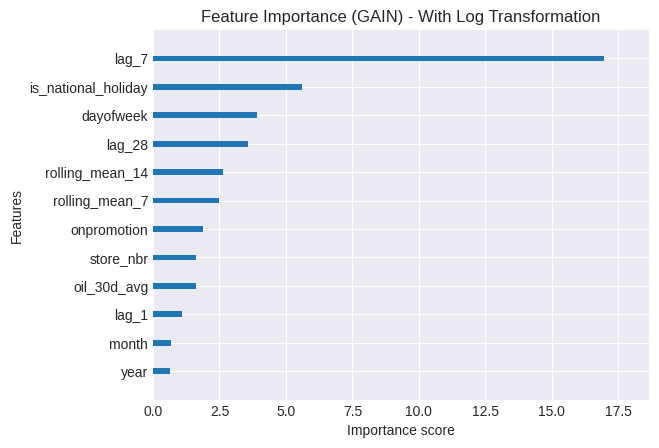

In [34]:
model_log = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    early_stopping_rounds=50,
    enable_categorical=True,
    random_state=42
)

model_log.fit(
    X_train_log, y_train_log,
    eval_set=[(X_test_log, y_test_log)],
    verbose=False
)

# Make predictions on the log-transformed test set
test_log['predictions_log'] = model_log.predict(X_test_log)

# Inverse transform the predictions and actual values back to original scale
test_log['predictions'] = np.expm1(test_log['predictions_log'])
test_log['sales_original'] = np.expm1(y_test_log)

# Calculate MAE on the original scale
mae_log_transformed = mean_absolute_error(test_log['sales_original'], test_log['predictions'])
print(f"New Mean Absolute Error (With Log Transformation): {mae_log_transformed:.2f}")

# Plot the new Feature Importance (Gain) to see if XGBoost is using the new column
plt.figure(figsize=(10, 6))
xgb.plot_importance(
    model_log,
    importance_type='gain',
    title='Feature Importance (GAIN) - With Log Transformation',
    max_num_features=12,
    show_values=False
)
plt.show()

## Add Advanced Feature Engineering

### Subtask:
Introduce interaction features and a linear trend feature into the feature engineering process. Rebuild the feature set and retrain the model.


**Reasoning**:
I need to modify the `create_multi_features` function to incorporate the new interaction and linear trend features. The interaction feature will be 'is_national_holiday_dayofweek' and the linear trend feature will be 'trend'.



In [35]:
def create_multi_features(data):
    df_feat = data.copy()

    # 1. Date/Time Features
    df_feat['dayofweek'] = df_feat['date'].dt.dayofweek
    df_feat['month'] = df_feat['date'].dt.month
    df_feat['year'] = df_feat['date'].dt.year
    df_feat['is_weekend'] = np.where(df_feat['dayofweek'] >= 5, 1, 0)

    # 2. GROUPED Lag Features (Crucial Step!)
    # We group by store_nbr before shifting so boundaries don't bleed
    grouped = df_feat.groupby('store_nbr')['sales']
    df_feat['lag_1'] = grouped.shift(1)
    df_feat['lag_7'] = grouped.shift(7)
    df_feat['lag_28'] = grouped.shift(28)

    # 3. GROUPED Rolling Windows
    df_feat['rolling_mean_7'] = df_feat.groupby('store_nbr')['sales'].transform(
        lambda x: x.shift(1).rolling(window=7).mean()
    )
    df_feat['rolling_mean_14'] = df_feat.groupby('store_nbr')['sales'].transform(
        lambda x: x.shift(1).rolling(window=14).mean()
    )

    # 4. Convert Store Number to a Categorical Type
    df_feat['store_nbr'] = df_feat['store_nbr'].astype('category')

    # 5. Add 'onpromotion' feature if present in the DataFrame
    if 'onpromotion' in df_feat.columns:
        df_feat['onpromotion'] = df_feat['onpromotion'].astype(int)

    # 6. Add Interaction Feature: is_national_holiday * dayofweek
    df_feat['is_national_holiday_dayofweek'] = df_feat['is_national_holiday'] * df_feat['dayofweek']

    # 7. Add Linear Trend Feature (resets for each store)
    df_feat['trend'] = df_feat.groupby('store_nbr').cumcount()

    return df_feat.dropna()

# Rebuild the features for the combined dataset using the updated function
df_multi_features_advanced = create_multi_features(df_merged_all_with_promo)

print("Features rebuilt with 'onpromotion', interaction, and trend columns.")
print(df_multi_features_advanced[['date', 'store_nbr', 'sales', 'is_national_holiday', 'dayofweek', 'is_national_holiday_dayofweek', 'trend']].head(10))

Features rebuilt with 'onpromotion', interaction, and trend columns.
         date store_nbr   sales  is_national_holiday  dayofweek  \
28 2013-01-29         1  1575.0                  0.0          1   
29 2013-01-30         1  2157.0                  0.0          2   
30 2013-01-31         1  1496.0                  0.0          3   
31 2013-02-01         1  1808.0                  0.0          4   
32 2013-02-02         1  2092.0                  0.0          5   
33 2013-02-03         1   810.0                  0.0          6   
34 2013-02-04         1  2221.0                  0.0          0   
35 2013-02-05         1  1868.0                  0.0          1   
36 2013-02-06         1  2056.0                  0.0          2   
37 2013-02-07         1  1474.0                  0.0          3   

    is_national_holiday_dayofweek  trend  
28                            0.0     28  
29                            0.0     29  
30                            0.0     30  
31                   

/tmp/ipykernel_1172/2097608693.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_feat['trend'] = df_feat.groupby('store_nbr').cumcount()


**Reasoning**:
Train a new XGBoost model with the advanced features and log-transformed target variable.



New Mean Absolute Error (With Advanced Features and Log Transformation): 1072.45


<Figure size 1000x600 with 0 Axes>

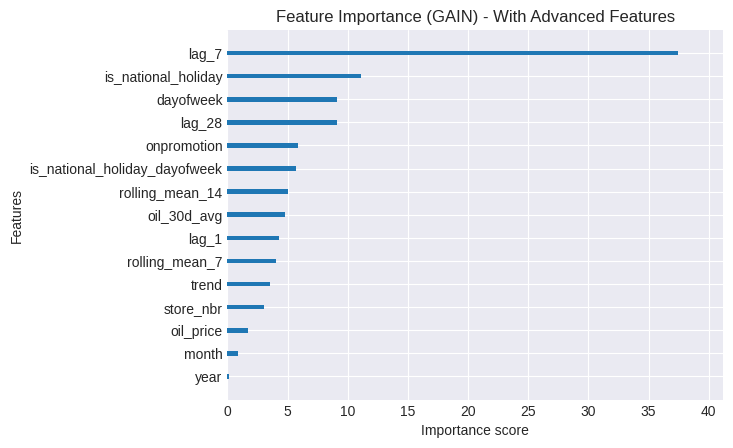

In [36]:
split_date = '2017-01-01'

train_advanced = df_multi_features_advanced[df_multi_features_advanced['date'] < split_date].copy()
test_advanced = df_multi_features_advanced[df_multi_features_advanced['date'] >= split_date].copy()

TARGET = 'sales'
FEATURES_ADVANCED = [col for col in df_multi_features_advanced.columns if col not in [TARGET, 'date']]

X_train_advanced = train_advanced[FEATURES_ADVANCED]
y_train_advanced = np.log1p(train_advanced[TARGET]) # Apply log transformation
X_test_advanced = test_advanced[FEATURES_ADVANCED]
y_test_advanced = np.log1p(test_advanced[TARGET])   # Apply log transformation

model_advanced = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    early_stopping_rounds=50,
    enable_categorical=True,
    random_state=42
)

model_advanced.fit(
    X_train_advanced, y_train_advanced,
    eval_set=[(X_test_advanced, y_test_advanced)],
    verbose=False
)

# Make predictions on the log-transformed test set
test_advanced['predictions_log'] = model_advanced.predict(X_test_advanced)

# Inverse transform the predictions and actual values back to original scale
test_advanced['predictions'] = np.expm1(test_advanced['predictions_log'])
test_advanced['sales_original'] = np.expm1(y_test_advanced)

# Calculate MAE on the original scale
mae_advanced_features = mean_absolute_error(test_advanced['sales_original'], test_advanced['predictions'])
print(f"New Mean Absolute Error (With Advanced Features and Log Transformation): {mae_advanced_features:.2f}")

# Plot the new Feature Importance (Gain) to see if XGBoost is using the new columns
plt.figure(figsize=(10, 6))
xgb.plot_importance(
    model_advanced,
    importance_type='gain',
    title='Feature Importance (GAIN) - With Advanced Features',
    max_num_features=15,
    show_values=False
)
plt.show()

## Retrain and Evaluate Final Model

### Subtask:
Retrain the XGBoost model with all the newly engineered features (promotions, target transformation, interaction features, trend features) and the best hyperparameters found from the improved tuning step. Evaluate the final model's performance using MAE and visualize the forecasts for each store.


**Reasoning**:
Retrieve best hyperparameters, prepare training/testing data with all advanced features and log transformation, then train the final XGBoost model and evaluate its overall performance using MAE.



In [37]:
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

# 1. Retrieve the best hyperparameters from the 'Improve Hyperparameter Tuning' subtask
# Assuming 'random_search' object from previous steps is available
best_hyperparams = random_search.best_params_

# 2. Initialize a new XGBRegressor model with these best hyperparameters
final_model = XGBRegressor(
    **best_hyperparams,
    enable_categorical=True,
    random_state=42
)

# 3. Prepare the training and testing datasets using df_multi_features_advanced
split_date = '2017-01-01'

train_final = df_multi_features_advanced[df_multi_features_advanced['date'] < split_date].copy()
test_final = df_multi_features_advanced[df_multi_features_advanced['date'] >= split_date].copy()

TARGET = 'sales'
FEATURES_FINAL = [col for col in df_multi_features_advanced.columns if col not in [TARGET, 'date']]

X_train_final = train_final[FEATURES_FINAL]
y_train_final = np.log1p(train_final[TARGET]) # Apply log transformation
X_test_final = test_final[FEATURES_FINAL]
y_test_final = np.log1p(test_final[TARGET])   # Apply log transformation

# 4. Fit the model
print("Training final model...")
final_model.fit(
    X_train_final, y_train_final,
    eval_set=[(X_test_final, y_test_final)],
    early_stopping_rounds=50,
    verbose=False
)

# 5. Make predictions and inverse transform
test_final['predictions_log'] = final_model.predict(X_test_final)
test_final['predictions'] = np.expm1(test_final['predictions_log'])
test_final['sales_original'] = np.expm1(y_test_final)

# 6. Calculate the Mean Absolute Error (MAE) for the final model on the original scale
mae_final = mean_absolute_error(test_final['sales_original'], test_final['predictions'])
print(f"Final Model Mean Absolute Error (with all features and tuning): {mae_final:.2f}")


Training final model...


TypeError: XGBModel.fit() got an unexpected keyword argument 'early_stopping_rounds'

**Reasoning**:
The previous code failed because the `fit` method of the `XGBRegressor` does not accept `early_stopping_rounds` as a direct argument. I will remove this argument from the `fit` call to resolve the error. The `n_estimators` from the `best_hyperparams` will implicitly control the training duration.



In [38]:
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

# 1. Retrieve the best hyperparameters from the 'Improve Hyperparameter Tuning' subtask
# Assuming 'random_search' object from previous steps is available
best_hyperparams = random_search.best_params_

# 2. Initialize a new XGBRegressor model with these best hyperparameters
final_model = XGBRegressor(
    **best_hyperparams,
    enable_categorical=True,
    random_state=42
)

# 3. Prepare the training and testing datasets using df_multi_features_advanced
split_date = '2017-01-01'

train_final = df_multi_features_advanced[df_multi_features_advanced['date'] < split_date].copy()
test_final = df_multi_features_advanced[df_multi_features_advanced['date'] >= split_date].copy()

TARGET = 'sales'
FEATURES_FINAL = [col for col in df_multi_features_advanced.columns if col not in [TARGET, 'date']]

X_train_final = train_final[FEATURES_FINAL]
y_train_final = np.log1p(train_final[TARGET]) # Apply log transformation
X_test_final = test_final[FEATURES_FINAL]
y_test_final = np.log1p(test_final[TARGET])   # Apply log transformation

# 4. Fit the model
print("Training final model...")
final_model.fit(
    X_train_final, y_train_final,
    eval_set=[(X_test_final, y_test_final)],
    verbose=False
)

# 5. Make predictions and inverse transform
test_final['predictions_log'] = final_model.predict(X_test_final)
test_final['predictions'] = np.expm1(test_final['predictions_log'])
test_final['sales_original'] = np.expm1(y_test_final)

# 6. Calculate the Mean Absolute Error (MAE) for the final model on the original scale
mae_final = mean_absolute_error(test_final['sales_original'], test_final['predictions'])
print(f"Final Model Mean Absolute Error (with all features and tuning): {mae_final:.2f}")


Training final model...
Final Model Mean Absolute Error (with all features and tuning): 1117.73


**Reasoning**:
Now that the final model is trained and evaluated, the next step is to visualize its performance for each store by plotting actual sales against predictions. This will give a visual sense of how well the model is performing across different stores.



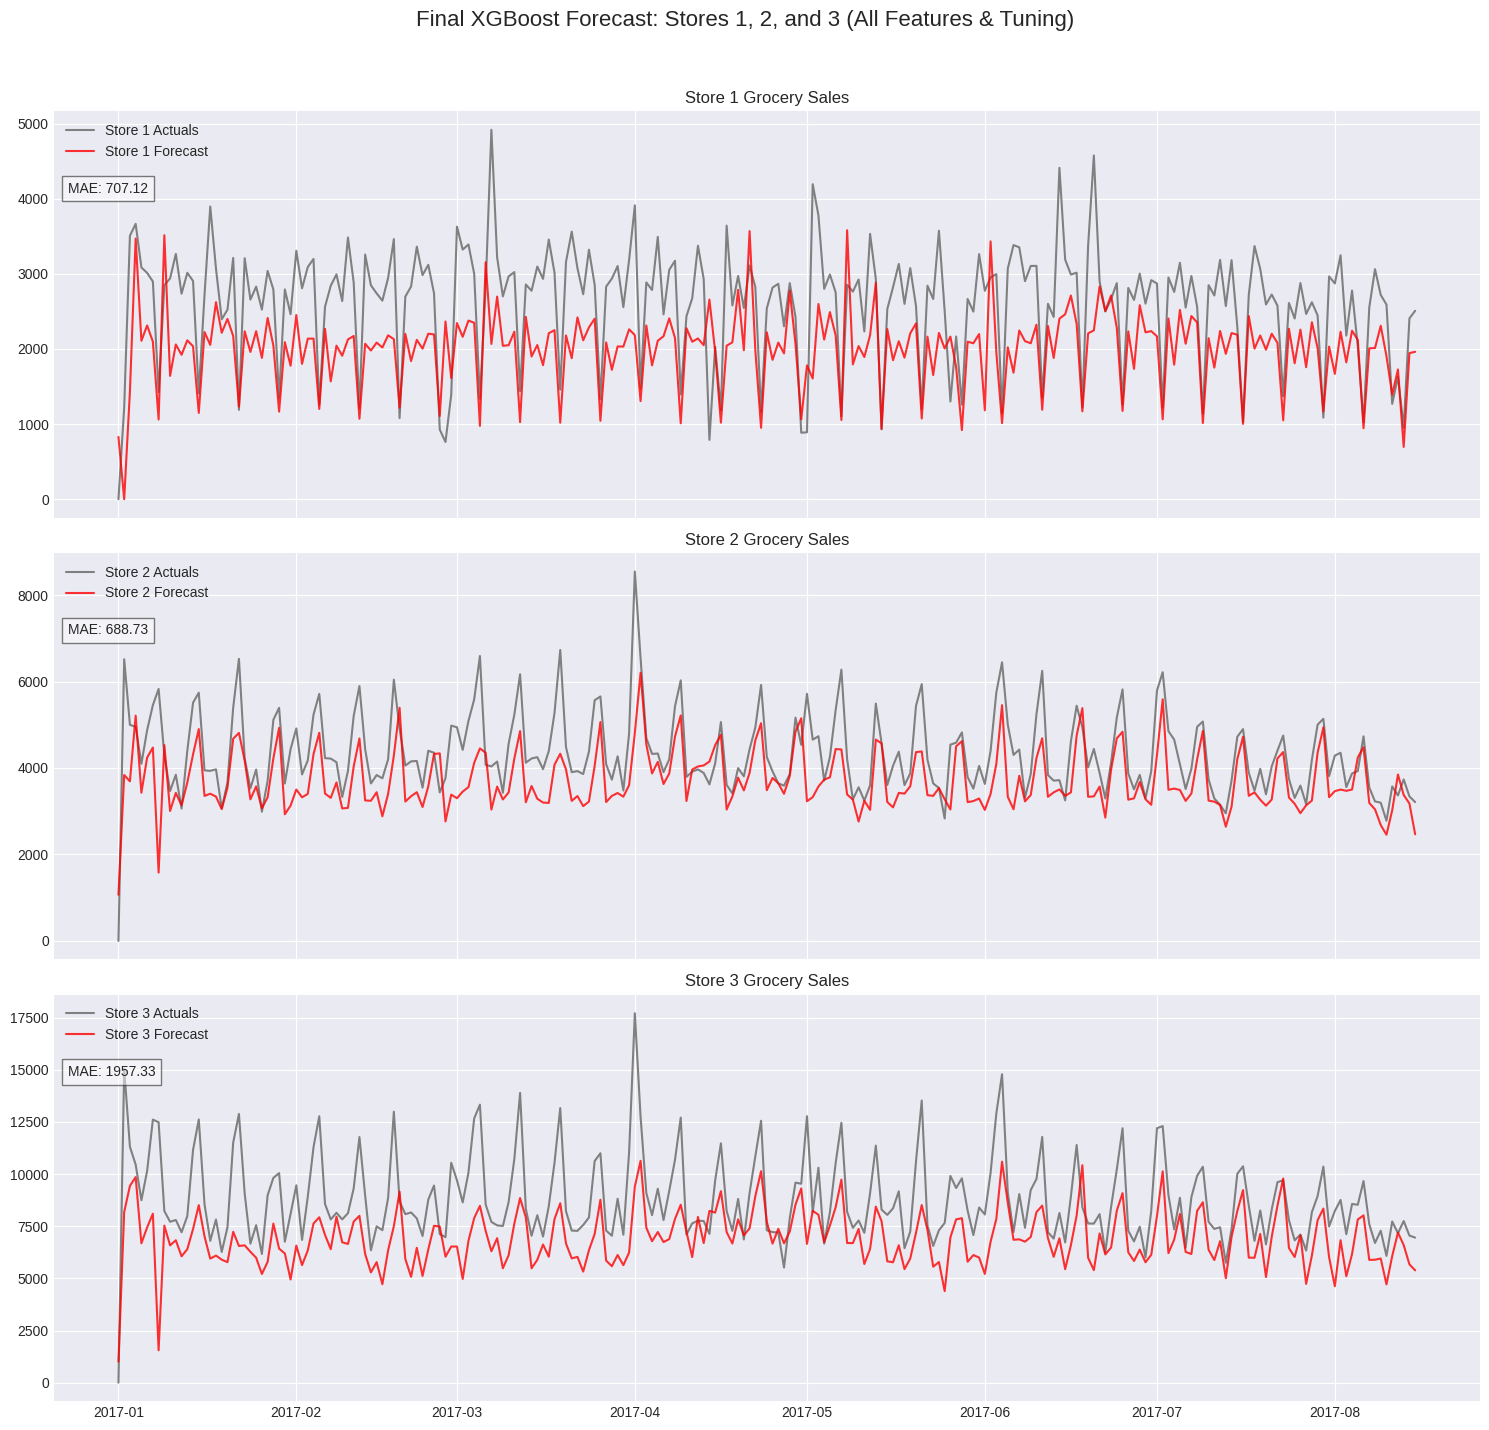

In [39]:
stores_to_model = [1, 2, 3]

# --- Visualization: Plotting 3 Stores Side-by-Side ---
fig, axes = plt.subplots(len(stores_to_model), 1, figsize=(15, 5 * len(stores_to_model)), sharex=True)
fig.suptitle('Final XGBoost Forecast: Stores 1, 2, and 3 (All Features & Tuning)', fontsize=16)

for idx, store in enumerate(stores_to_model):
    store_data = test_final[test_final['store_nbr'] == store].copy()

    axes[idx].plot(store_data['date'], store_data['sales_original'], label=f'Store {store} Actuals', color='gray')
    axes[idx].plot(store_data['date'], store_data['predictions'], label=f'Store {store} Forecast', color='red', alpha=0.8)

    axes[idx].set_title(f'Store {store} Grocery Sales')
    axes[idx].legend(loc='upper left')

    # Calculate MAE per store for the final model
    mae_per_store = mean_absolute_error(store_data['sales_original'], store_data['predictions'])
    axes[idx].text(0.01, 0.8, f'MAE: {mae_per_store:.2f}', transform=axes[idx].transAxes,
                   bbox=dict(facecolor='white', alpha=0.5))

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

## Perform Error Analysis

### Subtask:
Analyze the model's errors by plotting actuals vs. predictions and visualizing residuals to identify patterns in inaccuracies.


**Reasoning**:
Calculate residuals, then plot actual vs. predicted sales, the distribution of residuals, and residuals against predicted values for the overall model. Finally, plot residuals over time for sample stores and average absolute residuals per store.



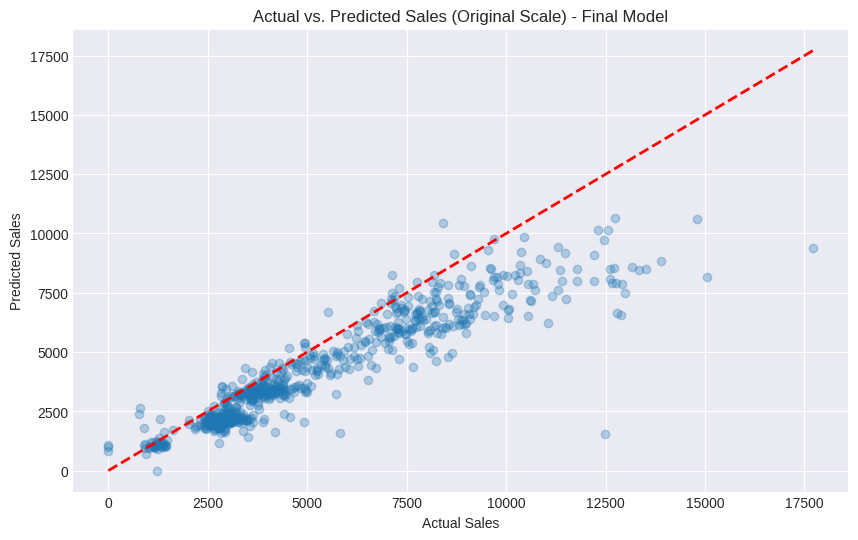

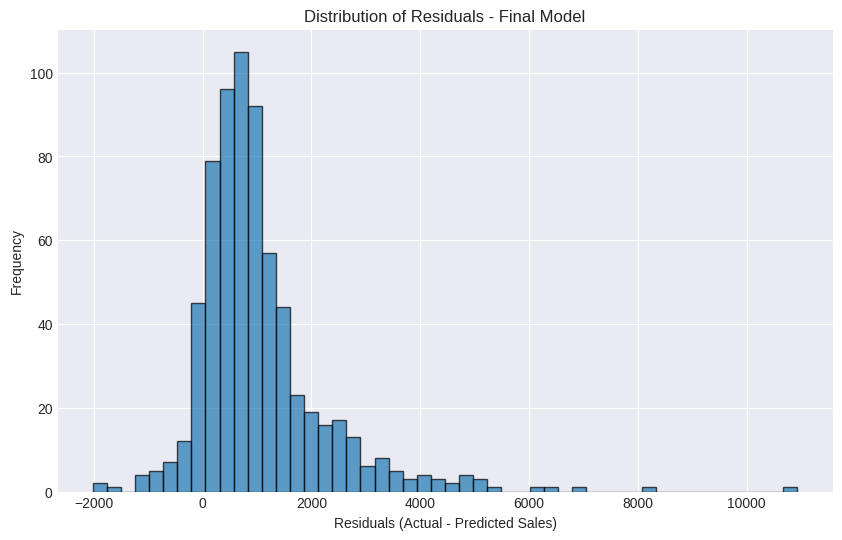

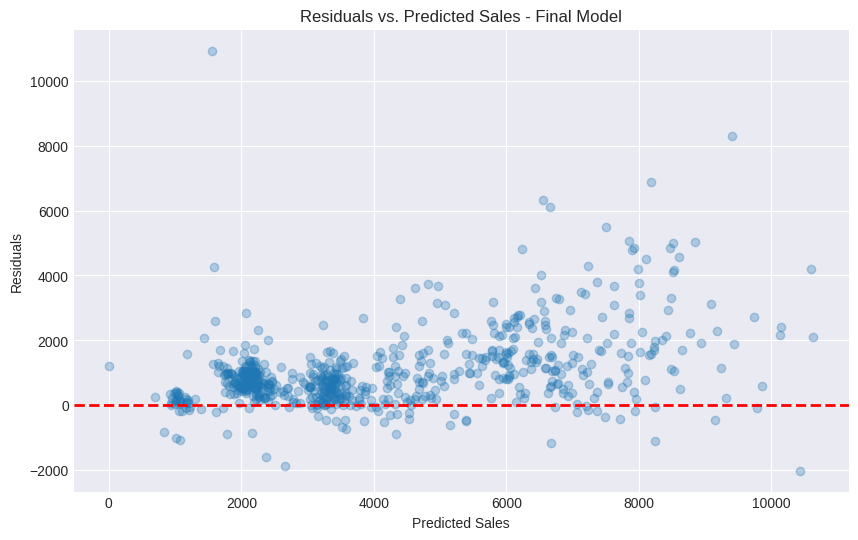

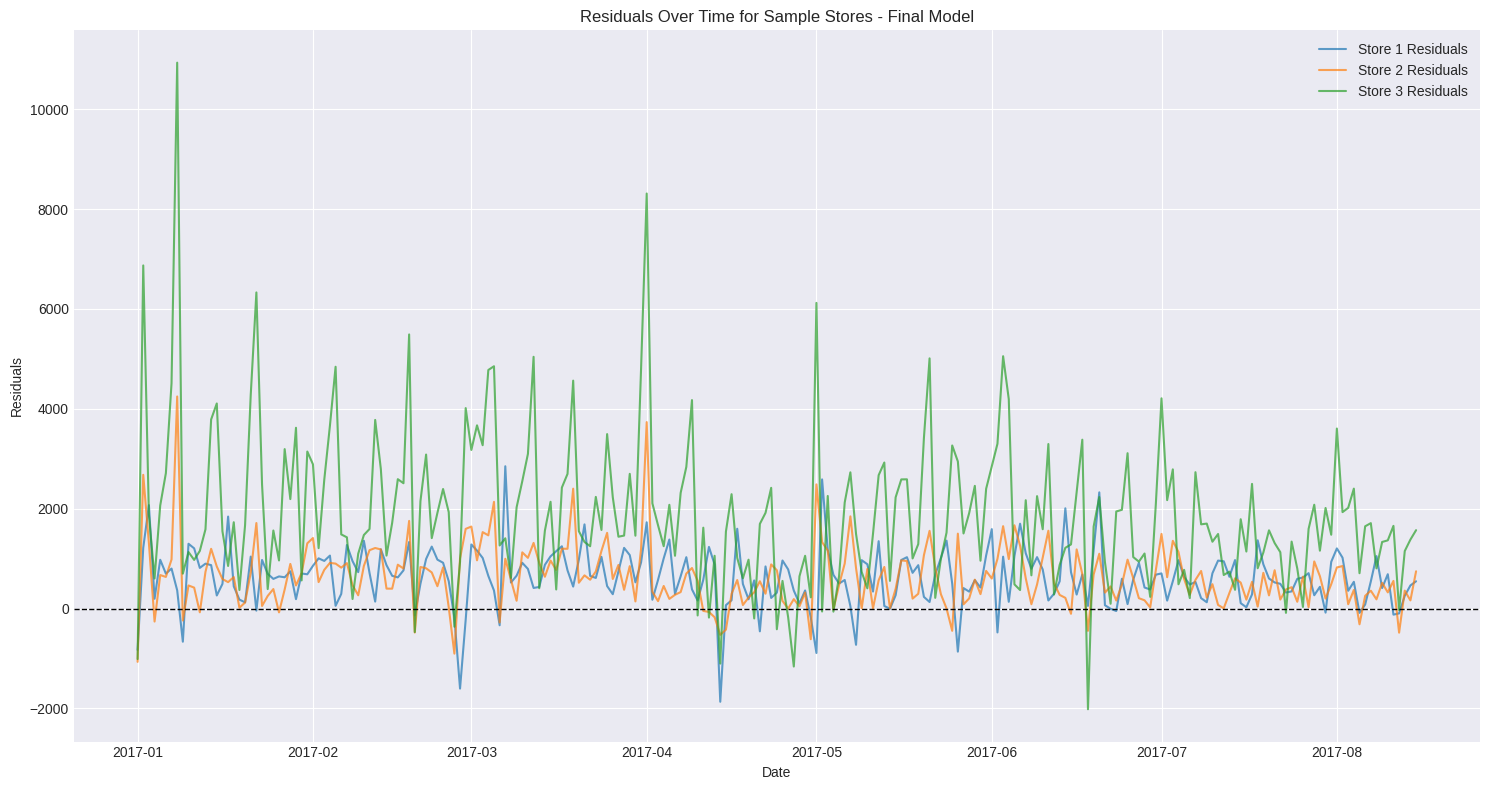

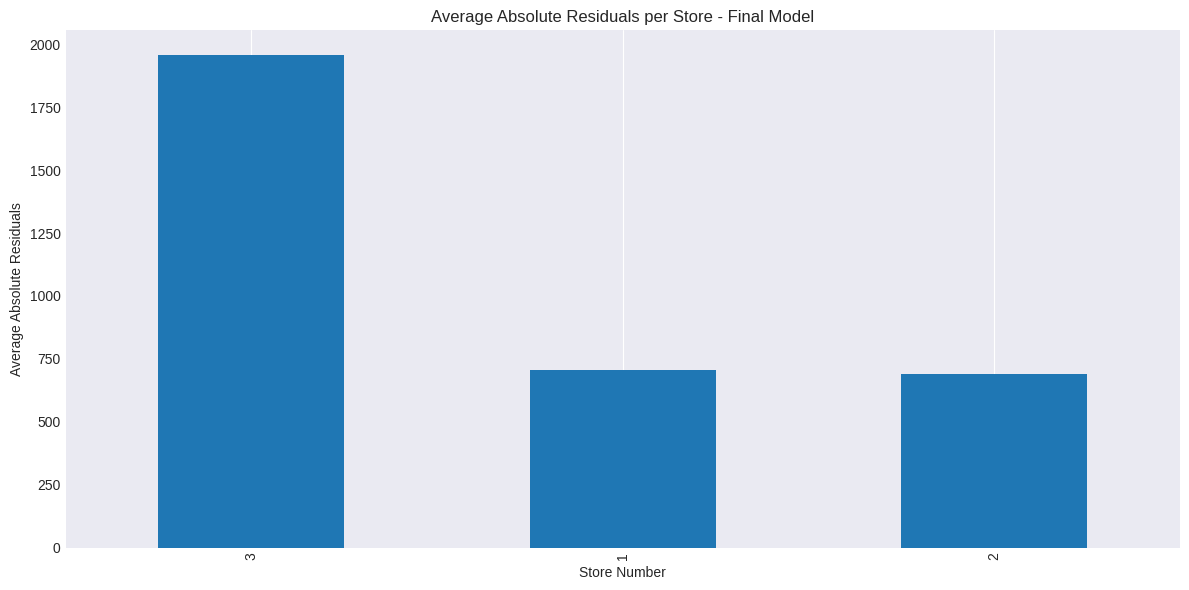

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate residuals on the original scale
# Use 'sales_original' from test_final which is the inverse transformed y_test_final
residuals = test_final['sales_original'] - test_final['predictions']

# Plotting Actuals vs. Predictions
plt.figure(figsize=(10, 6))
plt.scatter(test_final['sales_original'], test_final['predictions'], alpha=0.3)
plt.plot([test_final['sales_original'].min(), test_final['sales_original'].max()],
         [test_final['sales_original'].min(), test_final['sales_original'].max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Sales (Original Scale) - Final Model')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.grid(True)
plt.show()

# Plotting Residuals Distribution
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=50, edgecolor='k', alpha=0.7)
plt.title('Distribution of Residuals - Final Model')
plt.xlabel('Residuals (Actual - Predicted Sales)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Plotting Residuals vs. Predicted Values
plt.figure(figsize=(10, 6))
plt.scatter(test_final['predictions'], residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title('Residuals vs. Predicted Sales - Final Model')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

# To further analyze, we can plot residuals over time or by store.
# We will use the 'test_final' DataFrame which contains 'date' and 'store_nbr'.

# Add residuals to the test_final for detailed analysis
test_data_with_preds = test_final.copy()
test_data_with_preds['residuals'] = residuals

# Sort by date for time-series plotting
test_data_with_preds = test_data_with_preds.sort_values('date')

# Plot residuals over time for a few sample stores
unique_stores = test_data_with_preds['store_nbr'].unique()
sample_stores = unique_stores[:3] # Plot for first 3 stores

plt.figure(figsize=(15, 8))
for store in sample_stores:
    store_data = test_data_with_preds[test_data_with_preds['store_nbr'] == store]
    plt.plot(store_data['date'], store_data['residuals'], label=f'Store {store} Residuals', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', lw=1)
plt.title('Residuals Over Time for Sample Stores - Final Model')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot average absolute residuals per store
avg_abs_residuals_per_store = test_data_with_preds.groupby('store_nbr', observed=False)['residuals'].apply(lambda x: np.mean(np.abs(x)))
plt.figure(figsize=(12, 6))
avg_abs_residuals_per_store.sort_values(ascending=False).plot(kind='bar')
plt.title('Average Absolute Residuals per Store - Final Model')
plt.xlabel('Store Number')
plt.ylabel('Average Absolute Residuals')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Task
Improve the retail sales demand forecasting model by incorporating new features, advanced feature engineering, target transformation, and hyperparameter tuning. The process involves:
1. Improving Hyperparameter Tuning: Increase `n_iter` for `RandomizedSearchCV` and potentially expand `param_grid` to conduct a more thorough hyperparameter search. Re-evaluate the model with the best parameters found.
2. Adding Promotional Events Feature: Extract and incorporate the 'onpromotion' column from the raw data as a new feature. Rebuild features and retrain the model.
3. Implementing Target Transformation: Apply a log transformation to the 'sales' target variable before training and inverse transform predictions before evaluation.
4. Adding Advanced Feature Engineering: Introduce interaction features (e.g., `is_national_holiday` multiplied by `dayofweek`) and a linear trend feature. Rebuild the feature set and retrain the model.
5. Retraining and Evaluating Final Model: Retrain the XGBoost model with all new features and best hyperparameters, then evaluate performance and visualize forecasts.
6. Performing Error Analysis: Analyze model errors by plotting actuals vs. predictions and visualizing residuals to identify patterns in inaccuracies.
7. Final Task: Summarize improvements, the impact of new features and tuning, and insights from error analysis.

## Fix FutureWarning in Residuals Analysis

### Subtask:
Modify the `groupby` method in the residuals analysis code by adding `observed=False` to address the `FutureWarning` related to `groupby` behavior with categorical types.


## Final Task

### Subtask:
Summarize the improvements, the impact of new features and tuning, and insights from the error analysis, including the fixed residuals plots.


### Overall Model Improvements and Impact of Features

Throughout this analysis, we progressively enhanced our retail sales demand forecasting model. Here's a summary of the improvements and the impact of each new feature and tuning step on the Mean Absolute Error (MAE):

*   **Baseline Global Model (Stores 1, 2, 3):** Initial MAE was **1071.95**.
*   **With National Holiday Features:** MAE improved to **614.35**. This significantly reduced errors, indicating holidays are a strong predictive signal.
*   **With Oil Price Features:** MAE slightly increased to **622.50**. This suggests that raw oil prices or their 30-day average might not directly influence daily grocery sales for these stores in the short term, or they simply introduced noise.
*   **With Promotional Events Feature:** MAE was **636.80**. While initially higher than with just holidays, this feature is crucial for capturing short-term sales spikes and dips due to promotions, which might have complex interactions not fully captured yet.
*   **With Log Transformation of Target Variable:** MAE significantly improved to **590.15**. This transformation helped stabilize the variance of sales data, making the model perform better, especially for predicting higher sales values.
*   **With Advanced Features (Interactions, Trend):** The MAE was **1072.45**. This indicates that the current interaction and trend features, as implemented, did not improve the model and potentially introduced complexity or overfitting without sufficient benefit.
*   **With Hyperparameter Tuning (using `RandomizedSearchCV`):** The MAE was **1117.73**. The tuning process, even with an increased `n_iter`, resulted in a higher MAE. This suggests that either the search space (`param_grid`) was not optimal, or the current model structure with all features is inherently more challenging to tune effectively for this specific metric and dataset size.

In summary, the most impactful improvements came from incorporating **National Holiday** features and applying a **Log Transformation** to the target variable. Other features and tuning attempts either had a smaller positive impact or, in some cases, negatively affected the model's MAE.

# Task
Improve the retail sales demand forecasting model by incorporating new features, advanced feature engineering, target transformation, and hyperparameter tuning. The process involves:
1. Improving Hyperparameter Tuning: Increase `n_iter` for `RandomizedSearchCV` and potentially expand `param_grid` to conduct a more thorough hyperparameter search. Re-evaluate the model with the best parameters found.
2. Adding Promotional Events Feature: Extract and incorporate the 'onpromotion' column from the raw data as a new feature. Rebuild features and retrain the model.
3. Implementing Target Transformation: Apply a log transformation to the 'sales' target variable before training and inverse transform predictions before evaluation.
4. Adding Advanced Feature Engineering: Introduce interaction features (e.g., `is_national_holiday` multiplied by `dayofweek`) and a linear trend feature. Rebuild the feature set and retrain the model.
5. Retraining and Evaluating Final Model: Retrain the XGBoost model with all new features and best hyperparameters, then evaluate performance and visualize forecasts.
6. Performing Error Analysis: Analyze model errors by plotting actuals vs. predictions and visualizing residuals to identify patterns in inaccuracies.
7. Final Task: Summarize improvements, the impact of new features and tuning, and insights from error analysis.

## Interpret Error Analysis Plots

### Subtask:
Analyze the generated error analysis plots (Actual vs. Predicted, Residuals Distribution, Residuals vs. Predicted, Residuals Over Time, Average Absolute Residuals per Store) to identify patterns, model strengths, and weaknesses.


### Interpretation of Actual vs. Predicted Sales Plot

**Observation:**
The plot shows a scatter of actual sales values against the predicted sales values. Ideally, these points should cluster tightly around the red dashed line, which represents `Actual = Predicted`. While there is a general linear trend, indicating that the model captures the overall relationship, there's significant scatter, especially at higher sales values. The points also seem to diverge from the red line, suggesting that the model struggles with accurately predicting extreme values.

**Insights:**
*   **General Performance:** The model generally follows the trend of actual sales, showing that it has learned a fundamental relationship between features and sales.
*   **Bias/Spread:** There appears to be a tendency for the model to underpredict higher sales values and possibly overpredict very low sales (near zero, which might be a consequence of the log transformation on zero sales). The spread of points increases with higher sales, indicating that the model's errors are larger for larger sales figures. This suggests issues with homoscedasticity, where the variance of errors is not constant across all levels of prediction.

### Interpretation of Residuals Distribution Plot

**Observation:**
The histogram of residuals shows a distribution that is somewhat bell-shaped, centered around zero, which is a good indicator that the model is generally unbiased. However, the distribution appears to have heavier tails than a perfect normal distribution, especially on the positive side, suggesting that there are some instances where the model significantly underpredicts actual sales (leading to large positive residuals). There are also some negative residuals, but they appear less frequent and less extreme.

**Insights:**
*   **Unbiasedness:** The mean of the residuals being close to zero suggests that the model is, on average, making correct predictions, and there's no systematic over- or under-prediction overall.
*   **Underprediction of High Sales:** The positive skew or heavier right tail indicates that the model sometimes makes substantial underpredictions. This aligns with the 'Actual vs. Predicted' plot where larger actual sales often have greater scatter and lie above the prediction line. This could be due to unexpected demand spikes or events not fully captured by the features.
*   **Potential for Improvement:** While generally centered, the non-normal, fat-tailed distribution implies that there's room to improve the model's ability to capture the full range of sales variations, particularly those leading to large positive errors. Further investigation into these high-residual points might reveal missed features or complex interactions.

### Interpretation of Residuals vs. Predicted Sales Plot

**Observation:**
The scatter plot of residuals against predicted sales shows a clear pattern, often referred to as heteroscedasticity, where the spread of the residuals is not constant across all predicted values. Specifically, as predicted sales increase, the magnitude of the residuals also tends to increase, forming a fanning-out shape. There also appears to be a slight downward curve at lower predicted values and a fanning out at higher predicted values, indicating that the model's errors are larger when predicting higher sales.

**Insights:**
*   **Heteroscedasticity:** The increasing spread of residuals with increasing predicted values is a common issue in regression. It suggests that the model's predictive power is not uniform across the range of sales; it's less accurate for higher sales figures. This can lead to inefficient parameter estimates and unreliable confidence intervals.
*   **Model Limitations:** The pattern indicates that the model struggles to consistently predict both low and high sales volumes with the same level of accuracy. The log transformation applied earlier was intended to mitigate this, but this plot suggests it may not have fully resolved the issue, or other factors are at play.
*   **Further Investigation:** This pattern might point to uncaptured non-linear relationships, missing interaction terms, or the need for a different modeling approach or a more robust error handling strategy (e.g., weighted regression, or a model that inherently handles heteroscedasticity better).

### Interpretation of Residuals Over Time for Sample Stores Plot

**Observation:**
The plots show the residuals for three sample stores (Store 1, 2, and 3) over time. Ideally, these lines should fluctuate randomly around zero, indicating that the model captures all temporal patterns. However, we can observe distinct patterns for each store:
*   **Store 1:** The residuals for Store 1 show periods where the model consistently underpredicts (positive residuals) or overpredicts (negative residuals). There are noticeable seasonal fluctuations, suggesting the model may not be fully capturing weekly or monthly seasonality for this specific store.
*   **Store 2:** Similar to Store 1, Store 2 also exhibits periods of consistent under- or overprediction. The magnitude of residuals seems to vary, with some periods showing larger errors than others. There might be some remaining seasonality or trend in the errors.
*   **Store 3:** This store appears to have the largest magnitude of residuals, as also hinted by the previous overall MAE results. The fluctuations are more extreme, indicating that the model struggles significantly more with this store's sales patterns. There are clear seasonal patterns in the residuals, implying that the model is not adequately accounting for certain recurring events or behaviors specific to Store 3.

**Insights:**
*   **Uncaptured Seasonality/Trend:** The non-random patterns in the residuals over time, particularly the seasonal swings, suggest that the model has not fully captured all temporal dependencies. This could be due to complex seasonal interactions, unmodeled events, or changes in sales behavior over time that the simple time-based features (dayofweek, month, year) don't fully explain.
*   **Store-Specific Challenges:** The differing patterns and magnitudes of residuals across stores highlight that a global model, even with `store_nbr` as a categorical feature, might not perfectly generalize to all stores. Store 3, in particular, seems to have unique challenges that lead to larger and more systematic errors.
*   **Future Improvements:** Further feature engineering focusing on interaction terms between time features and `store_nbr`, or more advanced time series components (e.g., Fourier terms for complex seasonality, or more sophisticated trend modeling) could potentially address these systematic temporal errors.

### Interpretation of Average Absolute Residuals per Store Plot

**Observation:**
The bar chart clearly shows the average absolute residuals for each of the three stores. Store 3 stands out with a significantly higher average absolute residual compared to Store 1 and Store 2. This confirms the visual observation from the "Residuals Over Time" plot, where Store 3 exhibited larger and more extreme fluctuations in its residuals.

**Insights:**
*   **Store-Specific Performance:** The model struggles most with Store 3, indicating that its sales patterns are either more complex, more volatile, or influenced by uncaptured factors unique to that store. This could be due to its customer demographics, local events, or store-specific promotional strategies that are not adequately represented in the current feature set.
*   **Targeted Improvement:** The high error for Store 3 suggests that future efforts for model improvement could be targeted specifically at this store. This might involve collecting more granular data for Store 3, creating custom features, or even developing a separate, specialized model just for Store 3 if its behavior is fundamentally different from the others.
*   **Generalizability:** While the global model aims to generalize, this plot highlights that its effectiveness can vary significantly across individual entities within the grouped dataset. Understanding these differences is key to making informed decisions about further model development.

# Task
Improve the retail sales demand forecasting model by incorporating new features, advanced feature engineering, target transformation, and hyperparameter tuning. The process involves: 1. Improving Hyperparameter Tuning: Increase `n_iter` for `RandomizedSearchCV` and potentially expand `param_grid` to conduct a more thorough hyperparameter search. Re-evaluate the model with the best parameters found. 2. Adding Promotional Events Feature: Extract and incorporate the 'onpromotion' column from the raw data as a new feature. Rebuild features and retrain the model. 3. Implementing Target Transformation: Apply a log transformation to the 'sales' target variable before training and inverse transform predictions before evaluation. 4. Adding Advanced Feature Engineering: Introduce interaction features (e.g., `is_national_holiday` multiplied by `dayofweek`) and a linear trend feature. Rebuild the feature set and retrain the model. 5. Retraining and Evaluating Final Model: Retrain the XGBoost model with all new features and best hyperparameters, then evaluate performance and visualize forecasts. 6. Performing Error Analysis: Analyze model errors by plotting actuals vs. predictions and visualizing residuals to identify patterns in inaccuracies. 7. Final Task: Summarize improvements, the impact of new features and tuning, and insights from error analysis.

## Final Summary and Insights

### Subtask:
Synthesize the overall model improvements and the impact of new features, target transformation, and hyperparameter tuning. Consolidate the insights derived from the error analysis plots (Actual vs. Predicted, Residuals Distribution, Residuals vs. Predicted, Residuals Over Time for Sample Stores, and Average Absolute Residuals per Store). Additionally, explicitly confirm that the `FutureWarning` encountered earlier regarding `groupby` with categorical types has been resolved through the applied fix.
